# Проект: Прогнозирование почасового спроса на аренду велосипедов для компании BikeSouth

## Описание проекта

Компания **BikeSouth** развивает городской велопрокат на юге России. Ключевая цель бизнеса -- *стабильное обеспечение горожан и туристов велосипедами*. Для этого логистической системе необходимо точно прогнозировать, сколько велосипедов будет арендовано в каждый конкретный час.

Ранее компания использовала простую линейную регрессию, однако её качество оказалось неудовлетворительным: модель плохо справлялась с особенностями погоды на черноморском побережье. Компания уверена, что ключ к стабильной работе -- точный прогноз почасового спроса, учитывающий реальные погодные и сезонные факторы.

**Наша задача** -- разработать модель машинного обучения, которая будет предсказывать количество арендованных велосипедов в каждый час, опираясь на погодные и календарные характеристики.



**Цели проекта:**
1. **Повысить точность прогнозов** почасового спроса на аренду велосипедов.
2. **Оптимизировать логистику** распределения велосипедов по станциям.
3. **Улучшить клиентский опыт** -- избегать ситуаций простоя (избыток велосипедов) и дефицита (нехватка велосипедов).


**Задачи проекта:**
1. **Запустить предоставленный пайплайн** с линейной регрессией и зафиксировать её метрики как baseline.
2. **Подготовить и исследовать данные** -- провести первичный анализ и EDA, выявить закономерности и сформулировать гипотезы.
3. **Подготовить данные и baseline-модели** -- создать кррректную схему валидации, избегая утечек данных.
4. **Обучить и оптимизировать модели** -- kNN и дерево решений, подобрать гиперпараметры с помощью Optuna, используя 5-фолдовую кросс-валидацию и метрику RMSE.
5. **Сравнить модели и выбрать лучшую** -- свести метрики в таблицу, проверить лучшую модель на тестовой выборке, сравнить с baseline.
6. **Интерпретировать результаты** -- проанализировать важность признаков, сделать выводы и дать рекомендации BikeSouth.

## Пайплайн с линейной регрессией

### Загрузка библиотек и данных, первичный осмотр

In [1]:
!pip install -q numpy==1.26.4 \
                scipy==1.13.1 \
                pandas==2.2.2 \
                scikit-learn==1.5.2 \
                joblib==1.4.2 \
                matplotlib==3.9.2 \
                seaborn==0.13.2 \
                optuna==3.6.1 \
                phik \
                --no-cache-dir

In [2]:
# Работа с данными
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# МО
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from scipy import stats

import phik
from phik import resources
from phik.report import plot_correlation_matrix

# Оптимизация гиперпараметров
import optuna

# Работа с файлами
import requests
import os
import joblib
import pickle

# Уведомления
import warnings
warnings.filterwarnings('ignore')

# Фикс воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Визуал
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Все библиотеки успешно импортированы!')

Все библиотеки успешно импортированы!


In [3]:
# Загрузка обучающего датасета
df_train = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s14_train_data.csv')

# Первичный осмотр
print('=' * 60)
print('РАЗМЕР ДАТАСЕТА')
print(f'Количество строк: {df_train.shape[0]}')
print(f'Количество столбцов: {df_train.shape[1]}')
print('\n')

print('=' * 60)
print('ПЕРВЫЕ 10 СТРОК ДАТАСЕТА')
display(df_train.head(10))
print('\n')

print('=' * 60)
print('ИНФОРМАЦИЯ О ТИПАХ ДАННЫХ')
df_train.info()
print('\n')

print('=' * 60)
print('СТАТИСТИЧЕСКОЕ ОПИСАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ')
display(df_train.describe())
print('\n')

print('=' * 60)
print('ПРОВЕРКА НА ПРОПУСКИ')
missing = df_train.isnull().sum()
missing_pct = (missing / len(df_train)) * 100
missing_df = pd.DataFrame({
    'Пропущено значений': missing,
    'Процент пропусков': missing_pct
})
display(missing_df[missing_df['Пропущено значений'] > 0] if missing_df['Пропущено значений'].sum() > 0 else 'Пропуски отсутствуют')

РАЗМЕР ДАТАСЕТА
Количество строк: 7008
Количество столбцов: 16


ПЕРВЫЕ 10 СТРОК ДАТАСЕТА


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686
5,9.7,76.0,0.0,1308.0,5.6,0.00,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,True,157
6,17.4,49.0,1.2,2000.0,6.5,0.00,0.0,0.0,Autumn,Holiday,Yes,False,True,False,False,1042
7,18.1,60.0,0.2,2000.0,10.2,0.00,0.0,0.0,Autumn,No Holiday,No,False,False,False,True,0
8,36.7,33.0,1.8,1911.0,17.7,3.24,0.0,0.0,Summer,No Holiday,Yes,False,False,False,False,569
9,7.0,57.0,0.7,1553.0,-0.9,0.79,0.0,0.0,Autumn,No Holiday,Yes,False,False,True,False,1027




ИНФОРМАЦИЯ О ТИПАХ ДАННЫХ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   object 
 9   Holiday                   7008 non-null   object 
 10  Functioning Day           7008 non-null   object 
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
count,7008.000000,6758.000000,6798.000000,6749.000000,7008.000000,6798.000000,6746.000000,6745.000000,7008.000000
mean,12.812914,58.200503,1.725228,1435.156764,4.021490,0.569885,0.146902,0.074752,705.606022
std,11.924688,20.340317,1.042956,607.291049,13.033377,0.866142,1.164118,0.438189,646.311790
min,-17.500000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,0.000000
25%,3.300000,42.000000,0.900000,936.000000,-4.700000,0.000000,0.000000,0.000000,190.750000
50%,13.500000,57.000000,1.500000,1691.000000,5.000000,0.010000,0.000000,0.000000,504.500000
75%,22.400000,74.000000,2.300000,2000.000000,14.800000,0.940000,0.000000,0.000000,1070.000000
max,39.400000,98.000000,7.400000,2000.000000,26.800000,3.520000,35.000000,8.800000,3556.000000




ПРОВЕРКА НА ПРОПУСКИ


,Пропущено значений,Процент пропусков
Humidity(%),250,3.567352
Wind speed (m/s),210,2.996575
Visibility (10m),259,3.695776
Solar Radiation (MJ/m2),210,2.996575
Rainfall(mm),262,3.738584
Snowfall (cm),263,3.752854


**Ключевые наблюдения по данным:**
1. Пропуски в 6 числовых столбцах.
2. Несогласованность в названиях (`Humidity(%)` vs `Visibility (10m)`, `Time_Period_Late Evening` vs `Time_Period_Evening`).
3. Целевая переменная `Rented Bike Count`:
   - Диапазон: от 0 до 3556
   - Среднее: ~706 велосипедов в час
   - Медиана: ~504 (распределение, вероятно, скошено вправо)
   - Стандартное отклонение: ~646.

### Загрузка пайплайна с линейной регрессией и оценка её метрик

In [4]:
# Собственная baseline-модель
# Загружаем данные
df_train_lr = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s14_train_data.csv')
df_test_lr = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s14_test_data.csv')

print(f'Обучающий датасет: {df_train_lr.shape}')
print(f'Тестовый датасет: {df_test_lr.shape}')
print()

# Отделяем признаки и целевую переменную
X_train_lr = df_train_lr.drop('Rented Bike Count', axis=1)
y_train_lr = df_train_lr['Rented Bike Count']

X_test_lr = df_test_lr.drop('Rented Bike Count', axis=1)
y_test_lr = df_test_lr['Rented Bike Count']

# Определяем типы признаков
categorical_features = ['Seasons', 'Holiday', 'Functioning Day']
numeric_features = ['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']
bool_features = ['Time_Period_Evening', 'Time_Period_Late Evening', 'Time_Period_Morning', 'Time_Period_Night']


# Создаём отдельные пайплайны для разных типов признаков
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

bool_pipeline = Pipeline(steps=[
    ('to_int', FunctionTransformer(lambda x: x.astype(int))),
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Объединяем
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features),
        ('bool', bool_pipeline, bool_features)
    ])

# Итоговый пайплайн
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])  

# Отделяем признаки и целевую переменную
X_train = df_train_lr.drop('Rented Bike Count', axis=1)
y_train = df_train_lr['Rented Bike Count']

X_test = df_test_lr.drop('Rented Bike Count', axis=1)
y_test = df_test_lr['Rented Bike Count']

# Обучаем пайплайн
baseline_pipeline.fit(X_train_lr, y_train_lr)

# Делаем предсказания
y_pred_train_lr = baseline_pipeline.predict(X_train_lr)
y_pred_test_lr = baseline_pipeline.predict(X_test_lr)

# Функция для расчёта метрик
def calculate_metrics (y_true, y_pred, dataset_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f'Метрики для {dataset_name}:')
    print(f'   RMSE: {rmse:.2f}')
    print(f'   R^2: {r2:.4f}')
    print(f'   MAE: {mae:.2f}')
    print()
    
    return rmse, r2, mae

# Рассчитываем метрики
print('=' * 60)
print('BASELINE: ЛИНЕЙНАЯ РЕГРЕССИЯ')
print('=' * 60)
train_metrics = calculate_metrics(y_train_lr, y_pred_train_lr, 'обучающей выборки')
test_metrics = calculate_metrics(y_test_lr, y_pred_test_lr, 'тестовой выборки')

# Сохраняем метрики для дальнейшего сравнения
baseline_results = {
    'model': 'Linear Regression (baseline)',
    'train_rmse': train_metrics[0],
    'train_r2': train_metrics[1],
    'train_mae': train_metrics[2],
    'test_rmse': test_metrics[0],
    'test_r2': test_metrics[1],
    'test_mae': test_metrics[2]
}

print('Метрики baseline сохранены:')
for key, value in baseline_results.items():
    if isinstance(value, float):
        print(f'   {key}: {value:.4f}')
    else:
        print(f'   {key}: {value}')

Обучающий датасет: (7008, 16)
Тестовый датасет: (1752, 16)

BASELINE: ЛИНЕЙНАЯ РЕГРЕССИЯ
Метрики для обучающей выборки:
   RMSE: 412.50
   R^2: 0.5926
   MAE: 309.15

Метрики для тестовой выборки:
   RMSE: 411.45
   R^2: 0.5863
   MAE: 312.53

Метрики baseline сохранены:
   model: Linear Regression (baseline)
   train_rmse: 412.4996
   train_r2: 0.5926
   train_mae: 309.1525
   test_rmse: 411.4545
   test_r2: 0.5863
   test_mae: 312.5313


**Выводы по baseline-модели:**
1. **Точность модели:**
   - RMSE ~**412 велосипедов** -- это средняя ошибка прогноза. При среднем спросе ~706 велосипедов в час, ошибка составляет около **58% от среднего значения**. Это очень высокая ошибка.
   - MAE ~**310 велосипедов** -- среднее абсолютное отклонение прогноза от факта.
   
2. **Объясняющая способность:**
   - R^2 ~**0.59** -- модель объясняет только ~59% дисперсии спроса. Оставшиеся ~41% -- это неучтённые закономерности (нелинейные зависимости, взаимодействия признаков).
   
3. **Переобучение:**
   - Метрики на train и test практически идентичны (RMSE: 412.50 vs 411.50). Это говорит о том, что **переобучения нет**, но модель **недообучена** -- она слишком простая для таких сложных зависимостей.
   
4. **Почему линейная регрессия не справляется:**
   - Спрос на велосипеды имеет **нелинейный характер**:
      - При низких температурах спрос низкий, при комфортных (20-25 градусов) -- высокий, при жаре -- снова снижается.
      - Влажность и осадки влияют не линейно, а порогово (дождь резко снижает спрос).
      - Время суток и сезон имеют сложные взаимодействия.
   - Линейная модель не может уловить эти нелинейные паттерны.
   
5. **Бизнес-интерпретация:**
   - Ошибка в **412 велосипедов** означает, что компания может либо недовыдать велосипеды (клиенты уходят), либо держать лишние (издержки на обслуживание и хранение).
   - Для стабильной логистики нужна более точная модель.

## Подготовка и исследование данных

### Загрузка датасета и первичный анализ

In [5]:
print('=' * 60)
print('ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ')
print('=' * 60)

# 1. Размер датасета
print(f'\n1. РАЗМЕР ДАТАСЕТА:')
print(f'   Количество строк: {df_train.shape[0]}')
print(f'   Количество столбцов: {df_train.shape[1]}')

# 2. Типы данных
print(f'\n2. ТИПЫ ДАННЫХ:')
df_types = pd.DataFrame({
    'Столбец': df_train.columns,
    'Тип данных': df_train.dtypes.values,
    'Пропусков': df_train.isnull().sum().values,
    'Процент пропусков': (df_train.isnull().sum() / len(df_train) * 100).values,
    'Уникальных значений': df_train.nunique().values
})
display(df_types)

# 3. Пропуски
print(f'\n3. ПРОПУСКИ:')
missing = df_train.isnull().sum()
missing_pct = (missing / len(df_train)) * 100
missing_df = pd.DataFrame({
    'Столбец': missing.index,
    'Пропущено': missing.values,
    'Процент': missing_pct.values
})
missing_df = missing_df[missing_df['Пропущено'] > 0].sort_values('Пропущено', ascending=False)
if len(missing_df) > 0:
    display(missing_df)
else:
    print('   Пропуски отсутствуют')

ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ

1. РАЗМЕР ДАТАСЕТА:
   Количество строк: 7008
   Количество столбцов: 16

2. ТИПЫ ДАННЫХ:


,Столбец,Тип данных,Пропусков,Процент пропусков,Уникальных значений
0,Temperature,float64,0,0.000000,541
1,Humidity(%),float64,250,3.567352,87
2,Wind speed (m/s),float64,210,2.996575,64
3,Visibility (10m),float64,259,3.695776,1697
4,Dew point temperature,float64,0,0.000000,547
5,Solar Radiation (MJ/m2),float64,210,2.996575,344
6,Rainfall(mm),float64,262,3.738584,53
7,Snowfall (cm),float64,263,3.752854,47
8,Seasons,object,0,0.000000,4
9,Holiday,object,0,0.000000,2



3. ПРОПУСКИ:


,Столбец,Пропущено,Процент
7,Snowfall (cm),263,3.752854
6,Rainfall(mm),262,3.738584
3,Visibility (10m),259,3.695776
1,Humidity(%),250,3.567352
2,Wind speed (m/s),210,2.996575
5,Solar Radiation (MJ/m2),210,2.996575


In [6]:
# 4. Уникальные значения категориальных признаков
print(f'\n4. УНИКАЛЬНЫЕ ЗНАЧЕНИЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:')
categorical_cols = ['Seasons', 'Holiday', 'Functioning Day']
for col in categorical_cols:
    print(f'\n   {col}:')
    print(f'   {df_train[col].unique()}')
    print(f'   Распределение:')
    print(df_train[col].value_counts())
    
# 5. Проверка булевых столбцов Time_Period
print(f'\n5. РАСПРЕДЕЛЕНИЕ ВРЕМЕННЫХ ПЕРИОДОВ:')
bool_cols = ['Time_Period_Evening', 'Time_Period_Late Evening', 'Time_Period_Morning', 'Time_Period_Night']
for col in bool_cols:
    print(f'   {col}: True = {df_train[col].sum()}, False = {len(df_train) - df_train[col].sum()}')
    
# 6. Первые строки датасета
print(f'\n6. ПЕРВЫЕ 5 СТРОК ДАТАСЕТА:')
display(df_train.head())

# 7. Основные статистики числовых признаков
print(f'\n7. СТАТИСТИКИ ЧИСЛОВЫХ ПРИЗНАКОВ:')
numeric_cols = df_train.select_dtypes(include=['float64', 'int64']).columns
display(df_train[numeric_cols].describe())


4. УНИКАЛЬНЫЕ ЗНАЧЕНИЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:

   Seasons:
   ['Autumn' 'Winter' 'Summer' 'Spring']
   Распределение:
Seasons
Autumn    1770
Spring    1758
Summer    1744
Winter    1736
Name: count, dtype: int64

   Holiday:
   ['Holiday' 'No Holiday']
   Распределение:
Holiday
No Holiday    6668
Holiday        340
Name: count, dtype: int64

   Functioning Day:
   ['Yes' 'No']
   Распределение:
Functioning Day
Yes    6766
No      242
Name: count, dtype: int64

5. РАСПРЕДЕЛЕНИЕ ВРЕМЕННЫХ ПЕРИОДОВ:
   Time_Period_Evening: True = 1168, False = 5840
   Time_Period_Late Evening: True = 1173, False = 5835
   Time_Period_Morning: True = 1172, False = 5836
   Time_Period_Night: True = 1753, False = 5255

6. ПЕРВЫЕ 5 СТРОК ДАТАСЕТА:


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686



7. СТАТИСТИКИ ЧИСЛОВЫХ ПРИЗНАКОВ:


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
count,7008.000000,6758.000000,6798.000000,6749.000000,7008.000000,6798.000000,6746.000000,6745.000000,7008.000000
mean,12.812914,58.200503,1.725228,1435.156764,4.021490,0.569885,0.146902,0.074752,705.606022
std,11.924688,20.340317,1.042956,607.291049,13.033377,0.866142,1.164118,0.438189,646.311790
min,-17.500000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,0.000000
25%,3.300000,42.000000,0.900000,936.000000,-4.700000,0.000000,0.000000,0.000000,190.750000
50%,13.500000,57.000000,1.500000,1691.000000,5.000000,0.010000,0.000000,0.000000,504.500000
75%,22.400000,74.000000,2.300000,2000.000000,14.800000,0.940000,0.000000,0.000000,1070.000000
max,39.400000,98.000000,7.400000,2000.000000,26.800000,3.520000,35.000000,8.800000,3556.000000


**Выводы по первичному анализу:**
1. **Пропуски:**
   - 6 числовых столбцов имеют пропуски (от 3% до 3.75%).
   - Категориальные и булевы признаки -- без пропусков.
   - Пропуски будем заполнять медианой.
2. **Типы данных:**
   - **Числовые** (float64): 8 признаков -- `Temperature`, `Humidity`, `Wind Speed`, `Visibility`, `Dew point`, `Solar Radiation`, `Rainfall`, `Snowfall`.
   - **Категориальные** (object): 3 признака -- `Seasons`, `Holiday`, `Functioning Day`.
   - **Булевы** (bool): 4 признака -- `Time_Period_*`.
   - **Целевая переменная** (int64): `Rented Bike Count`.
3. **Временные периоды:**
   - Скорее всего, в данных есть пересечение между периодами. Например, запись может быть одновременно и Morning и Evening или Night и Late_Evening. Выясним на этапе EDA.
   - Night - 1753, Morning - 1172, Evening - 1168, Late_Evening - 1173.
   - Распределение по периодам равномерное.
4. **Категориальные признаки:**
   - **Seasons**: равномерное распрееделение (~1700-1770 на сезон).
   - **Holiday**: сильный дисбаланс -- No Holiday 6668 (95%), Holiday 340 (5%).
   - **Functioning Day**: сильный дисбаланс -- Yes 6766 (95.5%), No 242 (3.5%).
5. **Наблюдения для новых признаков:**
   - Названия столбцов не унифицированы: `Humidity(%)`, `Wind speed (m/s)`, `Time_Period_Late Evening` -- есть пробелы и разные форматы.
   - Можно создать признак **ощущаемая температура** (взаимодействие температуры и влажности).
   - Можно создать признак **комфортная погода** (бинарный: температура 10-25 градусов, без осадков, ветер < 5 м/с).
   - Можно выделить **час-пик** (Morning + Evening) как отдельный признак.

### Создание новых признаков

In [7]:
# Создаём копию для работы
df = df_train.copy()

print('=' * 60)
print('СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ')
print('=' * 60)

# 1. Приводим названия сталбцов к единому виду
df.columns = ['temperature', 'humidity', 'wind_speed', 'visibility', 'dew_point_temperature', 'solar_radiation', 'rainfall', 
              'snowfall', 'seasons', 'holiday', 'functioning_day', 'time_period_evening', 'time_period_late_evening', 
              'time_period_morning', 'time_period_night', 'rented_bike_count']

print('Названия столбцов приведены к единому виду:')
print(df.columns.tolist())
print()

# 2. Признак "час-пик" (Morning + Evening)
df['is_rush_hour'] = ((df['time_period_morning'] == True) | (df['time_period_evening'] == True)).astype(int)
print('Создан признак is_rush_hour (утро+вечер = 1, остальное = 0)')
print(f"   Распределение: {df['is_rush_hour'].value_counts().to_dict()}")
print()

# 3. Признак "комфортная температура" (10-25 градусов)
df['comfortable_temperature'] = ((df['temperature'] >= 10) & (df['temperature'] <= 25)).astype(int)
print('Создан признак comfortable_temperature (10-25 градусов)')
print(f"   Распределение: {df['comfortable_temperature'].value_counts().to_dict()}")
print()

# 4. Признак "есть осадки" (дождь или снег)
df['has_precipitation'] = ((df['rainfall'] > 0) | (df['snowfall'] > 0)).astype(int)
print('Создан признак has_precipitation (дождь или снег = 1)')
print(f"   Распределение: {df['has_precipitation'].value_counts().to_dict()}")
print()

# 5. Признак "хорошая видимость" (> 1500 метров)
df['good_visibility'] = (df['visibility'] > 1500).astype(int)
print('Создан признак good_visibility (> 1500 = 1)')
print(f"   Распределение: {df['good_visibility'].value_counts().to_dict()}")
print()

# 6. Признак "сильный ветер" (> 5 м/с)
df['strong_wind'] = (df['wind_speed'] > 5).astype(int)
print('Создан признак strong_wind (> 5 м/с = 1)')
print(f"   Распределение: {df['strong_wind'].value_counts().to_dict()}")
print()

# 7. Ощущаемая температура (исходим из простого: если humidity > 70 и temperature > 25, то "душно")
df['stuffy'] = ((df['humidity'] > 70) & (df['temperature'] > 25)).astype(int)
print('Создан признак stuffy (влажность > 70% и t > 25 градусов = 1)')
print(f"   Распределение: {df['stuffy'].value_counts().to_dict()}")
print()

# 8. Признак времени суток: daytime
df['time_period_daytime'] = ((df['time_period_evening'] == 0) & (df['time_period_late_evening'] == 0) &
                             (df['time_period_morning'] ==0) & (df['time_period_night'] == 0)).astype(int)
print('Создан признак time_period_daytime (все 4 = 0)')
print(f"   Распределение: {df['time_period_daytime'].value_counts().to_dict()}")
print()

# Итоговый размер
print(f'Итоговый размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')

СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ
Названия столбцов приведены к единому виду:
['temperature', 'humidity', 'wind_speed', 'visibility', 'dew_point_temperature', 'solar_radiation', 'rainfall', 'snowfall', 'seasons', 'holiday', 'functioning_day', 'time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night', 'rented_bike_count']

Создан признак is_rush_hour (утро+вечер = 1, остальное = 0)
   Распределение: {0: 4668, 1: 2340}

Создан признак comfortable_temperature (10-25 градусов)
   Распределение: {0: 4086, 1: 2922}

Создан признак has_precipitation (дождь или снег = 1)
   Распределение: {0: 6301, 1: 707}

Создан признак good_visibility (> 1500 = 1)
   Распределение: {1: 3845, 0: 3163}

Создан признак strong_wind (> 5 м/с = 1)
   Распределение: {0: 6980, 1: 28}

Создан признак stuffy (влажность > 70% и t > 25 градусов = 1)
   Распределение: {0: 6747, 1: 261}

Создан признак time_period_daytime (все 4 = 0)
   Распределение: {0: 5266, 1: 1742}

Итоговый размер датасет

**Результаты создания признаков:**
   - `is_rush_hour` - 4668 (0), 2140 (1) - 33% времени - час-пик (утро+вечер).
   - `comfortable_temperature` - 4086 (0), 2922 (1) - 42% времени - комфортная температура.
   - `has_precipitation` - 6301 (0), 707 (1) - только 10% времени с осадками.
   - `good_visibility` - 3163 (0), 3845 (1) - 55% времени - хорошая видимость.
   - `strong_wind` - 6980 (0), 28 (1) - всего 28 часов с сильным ветром -- очень редкий признак, экстремальный дисбаланс, может быть бесполезен для моделей.
   - `stuffy` - 6747 (0), 261 (1) - 3.7% времени - душная погода.

### Исследовательский анализ данных

ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ (EDA)


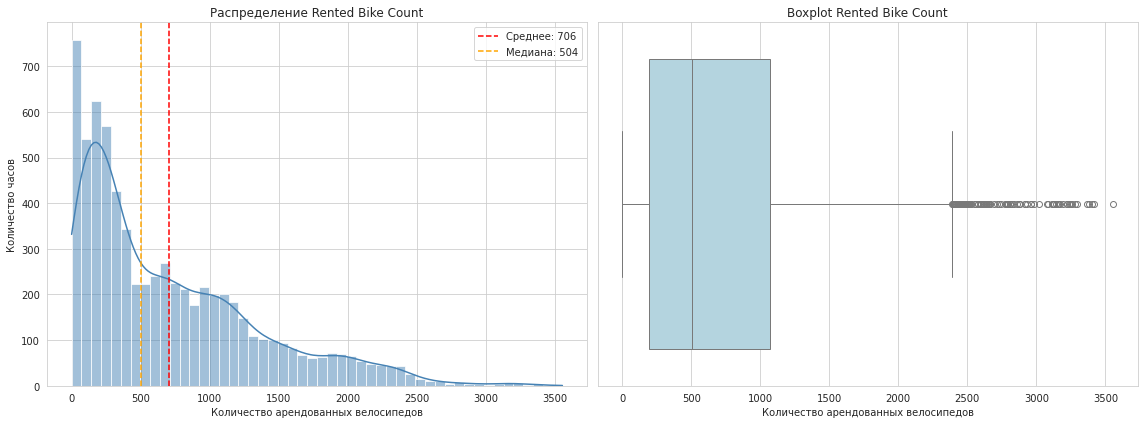

In [8]:
print('=' * 60)
print('ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ (EDA)')
print('=' * 60)

# 1. Распределение целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Гистограмма
sns.histplot(df['rented_bike_count'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение Rented Bike Count')
axes[0].set_xlabel('Количество арендованных велосипедов')
axes[0].set_ylabel('Количество часов')
axes[0].axvline(df['rented_bike_count'].mean(), color='red', linestyle='--', label=f"Среднее: {df['rented_bike_count'].mean():.0f}")
axes[0].axvline(df['rented_bike_count'].median(), color='orange', linestyle='--', label=f"Медиана: {df['rented_bike_count'].median():.0f}")
axes[0].legend()

# Boxplot
sns.boxplot(x=df['rented_bike_count'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot Rented Bike Count')
axes[1].set_xlabel('Количество арендованных велосипедов')

plt.tight_layout()
plt.show()

In [9]:
# 2. Статистики целевой переменной
print('\nСТАТИСТИКИ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:')
print(f"Среднее: {df['rented_bike_count'].median():.2f}")
print(f"Минимум: {df['rented_bike_count'].min()}")
print(f"Максимум: {df['rented_bike_count'].max()}")
print(f"Стандартное отклонение: {df['rented_bike_count'].std():.2f}")
print(f"Ассиметрия: {df['rented_bike_count'].skew():.2f}")
print(f"Эксцесс: {df['rented_bike_count'].kurtosis():.2f}")

# 3. Квартили
print('\nКВАРТИЛИ:')
print(f"Q1 (25%): {df['rented_bike_count'].quantile(0.25):.0f}")
print(f"Q2 (50%): {df['rented_bike_count'].quantile(0.5):.0f}")
print(f"Q3 (75%): {df['rented_bike_count'].quantile(0.75):.0f}")

# 4. Выбросы
Q1 = df['rented_bike_count'].quantile(0.25)
Q3 = df['rented_bike_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['rented_bike_count'] < lower_bound) | (df['rented_bike_count'] > upper_bound)]
print(f'\nВЫБРОСЫ:')
print(f'Нижняя граница: {lower_bound:.0f}')
print(f'Верхняя граница: {upper_bound:.0f}')
print(f'Количество выбросов: {len(outliers)} ({len(outliers) / len(df) * 100:.1f}%)')


СТАТИСТИКИ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:
Среднее: 504.50
Минимум: 0
Максимум: 3556
Стандартное отклонение: 646.31
Ассиметрия: 1.16
Эксцесс: 0.87

КВАРТИЛИ:
Q1 (25%): 191
Q2 (50%): 504
Q3 (75%): 1070

ВЫБРОСЫ:
Нижняя граница: -1128
Верхняя граница: 2389
Количество выбросов: 121 (1.7%)


**Наблюдения:**
1. **Распределение скошено вправо:**
   - Большинство часов - низкий спрос (медиана 504).
   - Есть "хвост" из часов с очень высоким спросом (до 3556).
   - Среднее (504.50) почти равно медиане (504) -- может быть случайностью.
2. **Выбросы:**
   - 121 час (1.7%) имеет спрос > 2389 велосипедов.
   - Это могут быть пиковые часы (праздники, идеальная погода).
   - Нижняя граница отрицательная (-1128) -- значит, низкий спрос не является выбросом (0 велосипедов -- норма).
3. **Разброс:**
   - Стандартное отклонение 646 при среднем 504 -- огромный разброс.
   - Спрос варьируется от 0 до 3556.

(ДОПОЛНЕНИЕ): ГРАФИЧЕСКИЙ АНАЛИЗ ПРИЗНАКОВ


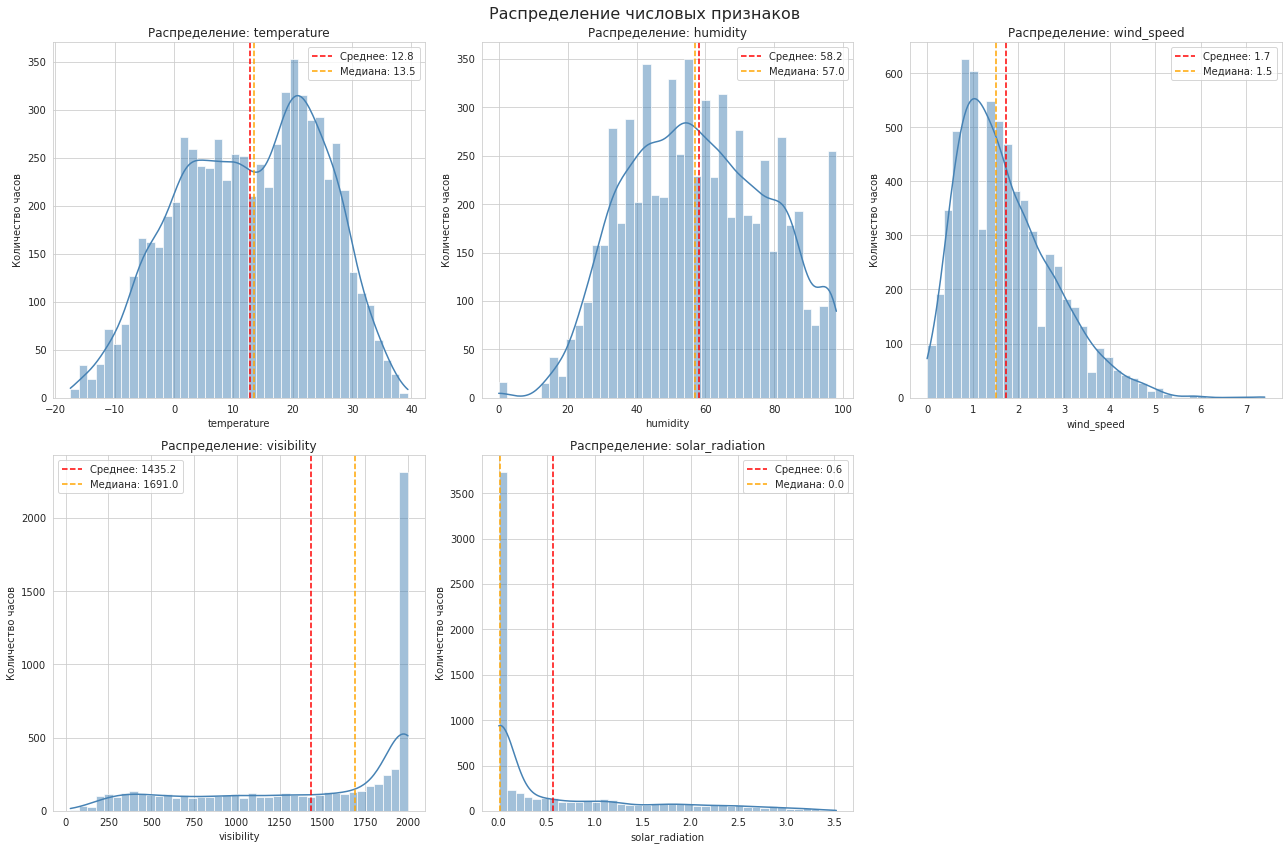

In [10]:
# Графический анализ всех признаков
print('=' * 60)
print('(ДОПОЛНЕНИЕ): ГРАФИЧЕСКИЙ АНАЛИЗ ПРИЗНАКОВ')
print('=' * 60)

# 1. Числовые признаки
numeric_cols = ['temperature', 'humidity', 'wind_speed', 'visibility', 'solar_radiation']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Гистограмма с KDE
    sns.histplot(df[col], bins=40, kde=True, ax=axes[i], color='steelblue')
    
    axes[i].set_title(f'Распределение: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Количество часов')
    
    # Добавляем среднее и медиану
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Среднее: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', label=f'Медиана: {df[col].median():.1f}')
    axes[i].legend()
    
# Убираем пустой сабплот
axes[5].set_visible(False)

plt.suptitle('Распределение числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

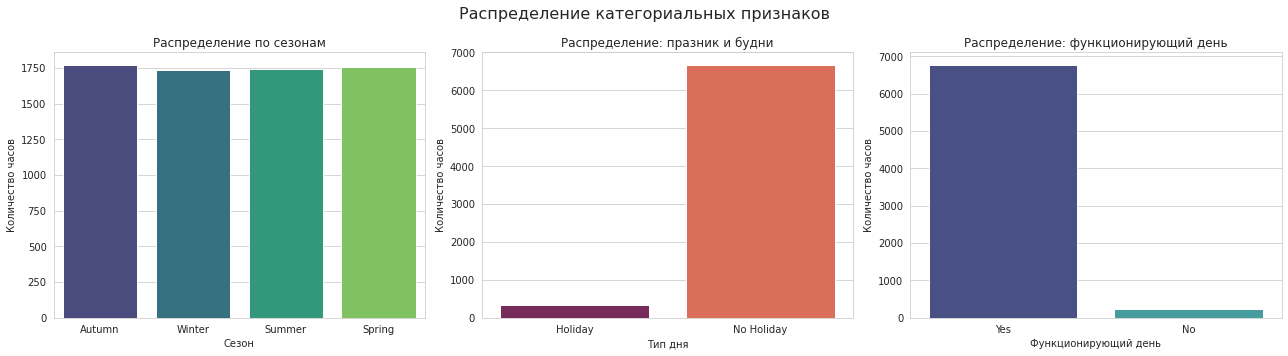

In [11]:
# 2. Категориальные признаки
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Seasons
sns.countplot(x='seasons', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Распределение по сезонам')
axes[0].set_xlabel('Сезон')
axes[0].set_ylabel('Количество часов')

# Holiday
sns.countplot(x='holiday', data=df, ax=axes[1], palette='rocket')
axes[1].set_title('Распределение: празник и будни')
axes[1].set_xlabel('Тип дня')
axes[1].set_ylabel('Количество часов')

# Functioning Day
sns.countplot(x='functioning_day', data=df, ax=axes[2], palette='mako')
axes[2].set_title('Распределение: функционирующий день')
axes[2].set_xlabel('Функционирующий день')
axes[2].set_ylabel('Количество часов')

plt.suptitle('Распределение категориальных признаков', fontsize=16)
plt.tight_layout()
plt.show()

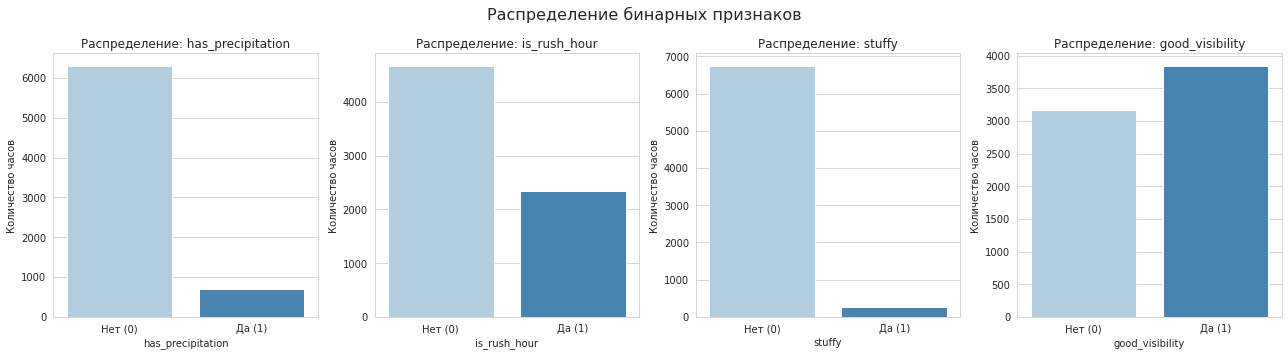

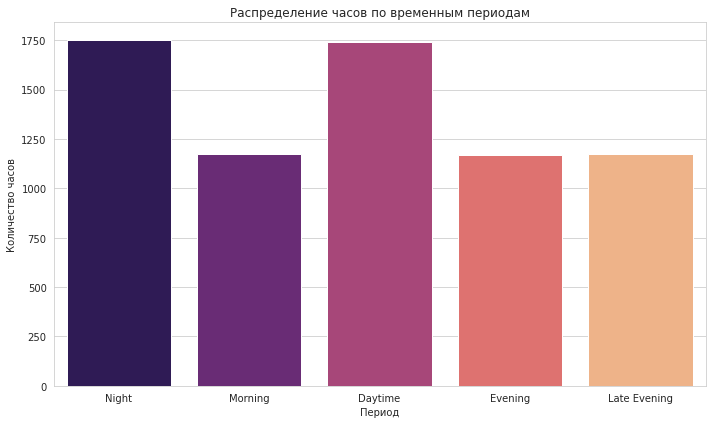

In [12]:
# 3. Бинарные признаки
binary_cols = ['has_precipitation', 'is_rush_hour', 'stuffy', 'good_visibility']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(binary_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='Blues')
    
    axes[i].set_title(f'Распределение: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Количество часов')
    axes[i].set_xticklabels(['Нет (0)', 'Да (1)'])
    
plt.suptitle('Распределение бинарных признаков', fontsize=16)
plt.tight_layout()
plt.show()

# 4. Временные периоды
time_period_cols = ['time_period_night', 'time_period_morning', 'time_period_daytime', 'time_period_evening', 'time_period_late_evening']

time_period_counts = []
for col in time_period_cols:
    time_period_counts.append({
        'Период': col.replace('time_period_', '').replace('_', ' ').title(),
        'Часов': df[col].sum()
    })
    
time_period_df = pd.DataFrame(time_period_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x='Период', y='Часов', data=time_period_df, palette='magma')
plt.title('Распределение часов по временным периодам')
plt.xlabel('Период')
plt.ylabel('Количество часов')
plt.tight_layout()
plt.show()

ЗАВИСИМОСТЬ СПРОСА ОТ ПОГОДНЫХ ФАКТОРОВ


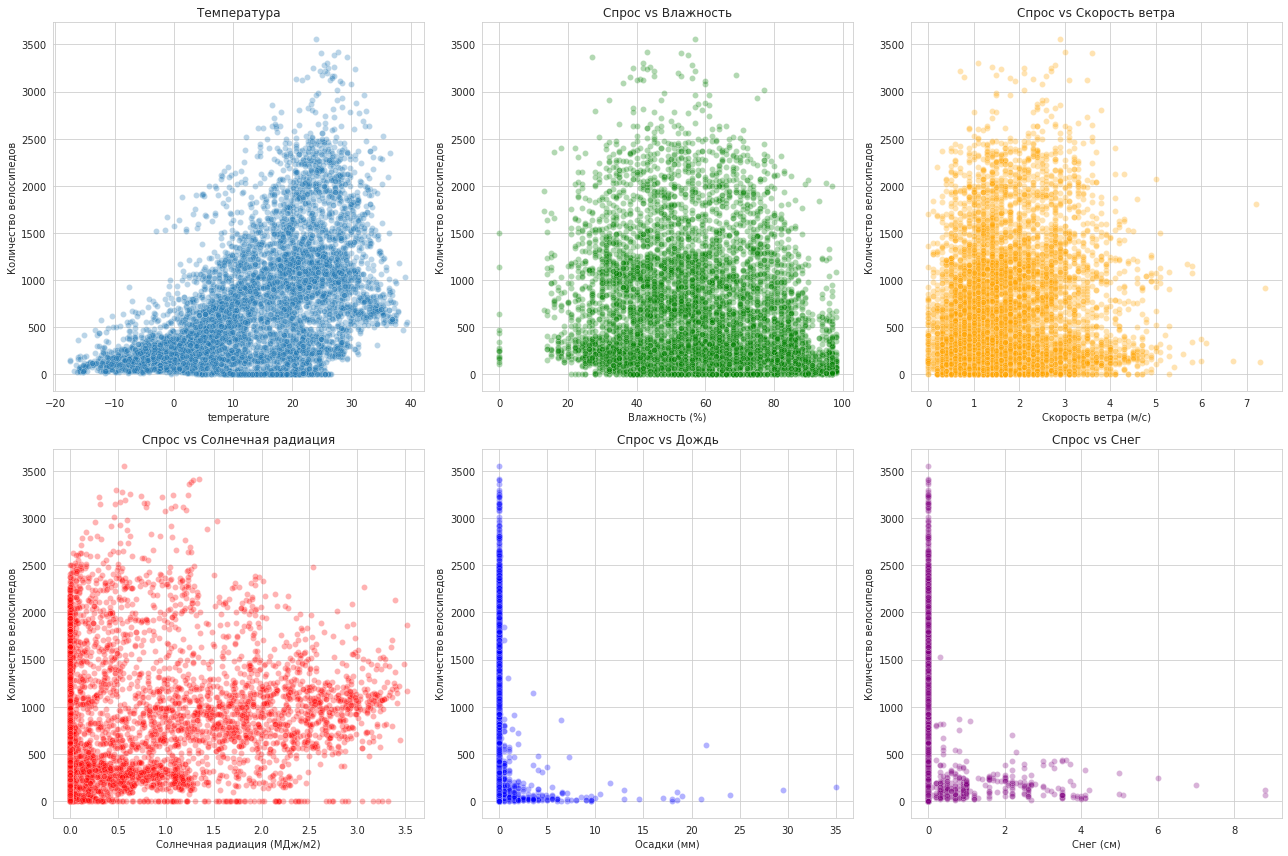

In [13]:
# Зависимость спроса от погоды
print('ЗАВИСИМОСТЬ СПРОСА ОТ ПОГОДНЫХ ФАКТОРОВ')
print('=' * 60)

# 1. Спрос и Температура
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# График 1: Температура
sns.scatterplot(x='temperature', y='rented_bike_count', data=df, alpha=0.3, ax=axes[0, 0])
axes[0, 0].set_title('Спрос vs Температура')
axes[0, 0].set_title('Температура')
axes[0, 0].set_ylabel('Количество велосипедов')

# График 2: Влажность
sns.scatterplot(x='humidity', y='rented_bike_count', data=df, alpha=0.3, ax=axes[0, 1], color='green')
axes[0, 1].set_title('Спрос vs Влажность')
axes[0, 1].set_xlabel('Влажность (%)')
axes[0, 1].set_ylabel('Количество велосипедов')

# График 3: Скорость ветра
sns.scatterplot(x='wind_speed', y='rented_bike_count', data=df, alpha=0.3, ax=axes[0, 2], color='orange')
axes[0, 2].set_title('Спрос vs Скорость ветра')
axes[0, 2].set_xlabel('Скорость ветра (м/с)')
axes[0, 2].set_ylabel('Количество велосипедов')

# График 4: Солнечная радиация
sns.scatterplot(x='solar_radiation', y='rented_bike_count', data=df, alpha=0.3, ax=axes[1, 0], color='red')
axes[1, 0].set_title('Спрос vs Солнечная радиация')
axes[1, 0].set_xlabel('Солнечная радиация (МДж/м2)')
axes[1, 0].set_ylabel('Количество велосипедов')

# График 5: Осадки (дождь)
sns.scatterplot(x='rainfall', y='rented_bike_count', data=df, alpha=0.3, ax=axes[1, 1], color='blue')
axes[1, 1].set_title('Спрос vs Дождь')
axes[1, 1].set_xlabel('Осадки (мм)')
axes[1, 1].set_ylabel('Количество велосипедов')

# График 6: Снег
sns.scatterplot(x='snowfall', y='rented_bike_count', data=df, alpha=0.3, ax=axes[1, 2], color='purple')
axes[1, 2].set_title('Спрос vs Снег')
axes[1, 2].set_xlabel('Снег (см)')
axes[1, 2].set_ylabel('Количество велосипедов')

plt.tight_layout()
plt.show()

In [14]:
# Числовой анализ зависимостей

# Средний спрос по диапазонам температур
df['temp_bin'] = pd.cut(df['temperature'], bins=[-20, 0, 10, 15, 20, 25, 30, 40], labels=['0', '0-10', '10-15', '15-20', '20-25', '25-30', '>30'])
print('СРЕДНИЙ СПРОС ПО ТЕМПЕРАТУРЕ:')
print(df.groupby('temp_bin', observed=True)['rented_bike_count'].agg(['mean', 'median', 'count']))
print()

# Средний спрос по осадкам
df['rain_bin'] = pd.cut(df['rainfall'], bins=[-0.1, 0, 1, 5, 10, 40], labels=['0', '0-1', '1-5', '5-10', '>10'])
print('СРЕДНИЙ СПРОС ПО ОСАДКАМ:')
print(df.groupby('rain_bin', observed=True)['rented_bike_count'].agg(['mean', 'median', 'count']))
print()

# Средний спрос по солнечной радиации
df['solar_bin'] = pd.cut(df['solar_radiation'], bins=[-0.1, 0, 0.5, 1.0, 1.5, 2.0, 4.0], labels=['0', '0-0.5', '0.5-1.0', '1.0-1.5', '1.5-2.0', '>2.0'])
print('СРЕДНИЙ СПРОС ПО СОЛНЕЧНОЙ РАДИАЦИИ:')
print(df.groupby('solar_bin', observed=True)['rented_bike_count'].agg(['mean', 'median', 'count']))

СРЕДНИЙ СПРОС ПО ТЕМПЕРАТУРЕ:
                 mean  median  count
temp_bin                            
0          201.388747   170.0   1173
0-10       428.456434   333.0   1733
10-15      666.459233   629.5    834
15-20      850.690155   810.0    965
20-25     1050.910407  1005.0   1105
25-30     1235.110553  1106.0    796
>30       1106.955224   910.0    402

СРЕДНИЙ СПРОС ПО ОСАДКАМ:
                mean  median  count
rain_bin                           
0         739.346172   565.0   6361
0-1       228.450980   124.5    204
1-5        98.633588    35.0    131
5-10       69.852941    22.0     34
>10        98.687500    56.0     16

СРЕДНИЙ СПРОС ПО СОЛНЕЧНОЙ РАДИАЦИИ:
                 mean  median  count
solar_bin                           
0          486.146283   273.5   3336
0-0.5      865.803808   600.0   1208
0.5-1.0    886.496000   632.0    625
1.0-1.5    981.760870   859.5    506
1.5-2.0    976.242788   912.5    416
>2.0       960.533239   987.0    707


**Наблюдения:**
1. **Температура** -> Спрос (явная нелинейность): спрос растёт с температурой до ~27 градусов, затем начинает снижаться. Это классическая нелинейная зависимость.
2. **Осадки** -> Спрос (пороговый эффект): даже небольшой дождь (0-1 мм) **снижает спрос в 3 раза**. При осадках > 1 мм спрос падает в 7-10 раз. Это **пороговый эффект**, который линейная модель не может смоделировать.
3. **Солнечная радиация** -> Спрос (насыщение): спрос резко растёт при появлении солнца (0 -> 0.5), затем выходит на **плато** (~950-980). Дальнейшее увеличение радиации не повышает спрос -- **эффект насыщения**.

**Гипотезы для нелинейных моделей:**
1. Температура -- нелинейная зависимость (оптимум 23-28 градусов, при жаре спрос падает).
2. Осадки -- бинарный порог: любой дождь (и снег) снижает спрос.
3. Солнечная радиация -- нелинейная с насыщением.
4. Влажность -- возможно, нелинейное взаимодействие с температурой.
5. Сезоны и время суток -- сильные категориальные факторы, проверим.

СЕЗОНЫ, ПРАЗДНИКИ, ВРЕМЯ СУТОК


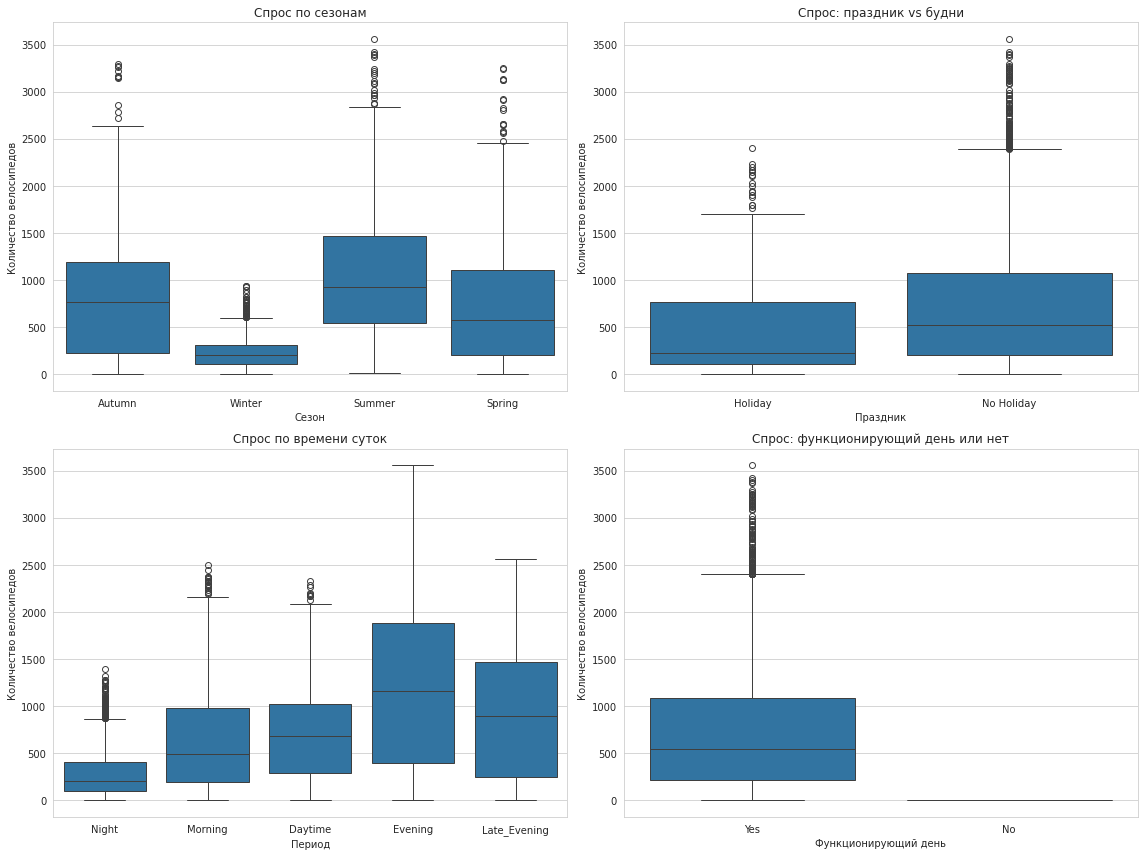

In [15]:
print('=' * 60)
print('СЕЗОНЫ, ПРАЗДНИКИ, ВРЕМЯ СУТОК')
print('=' * 60)

# 1. Спрос по сезонам
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(x='seasons', y='rented_bike_count', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Спрос по сезонам')
axes[0, 0].set_xlabel('Сезон')
axes[0, 0].set_ylabel('Количество велосипедов')

# 2. Спрос: праздник vs будни
sns.boxplot(x='holiday', y='rented_bike_count', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Спрос: праздник vs будни')
axes[0, 1].set_xlabel('Праздник')
axes[0, 1].set_ylabel('Количество велосипедов')

# 3. Спрос по времени суток
def get_time_period_label(row):
    if row['time_period_night'] == 1:
        return 'Night'
    elif row['time_period_morning'] == 1:
        return 'Morning'
    elif row['time_period_evening'] == 1:
        return 'Evening'
    elif row['time_period_late_evening'] == 1:
        return 'Late_Evening'
    else:
        return 'Daytime'
    
df['time_period_label'] = df.apply(get_time_period_label, axis=1)

sns.boxplot(x='time_period_label', y='rented_bike_count', data=df, order=['Night', 'Morning', 'Daytime', 'Evening', 'Late_Evening'], ax=axes[1, 0])
axes[1, 0].set_title('Спрос по времени суток')
axes[1, 0].set_xlabel('Период')
axes[1, 0].set_ylabel('Количество велосипедов')

# 4. Спрос: функционирующий день vs нет
sns.boxplot(x='functioning_day', y='rented_bike_count', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Спрос: функционирующий день или нет')
axes[1, 1].set_xlabel('Функционирующий день')
axes[1, 1].set_ylabel('Количество велосипедов')

plt.tight_layout()
plt.show()

In [16]:
# Числовые сводки
print('\nСРЕДНИЙ СПРОС ПО СЕЗОНАМ:')
print(df.groupby('seasons')['rented_bike_count'].agg(['mean', 'median', 'count']))
print()

print('СРЕДНИЙ СПРОС: ПРАЗДНИК vs БУДНИ:')
print(df.groupby('holiday')['rented_bike_count'].agg(['mean', 'median', 'count']))
print()

print('СРЕДНИЙ СПРОС ПО ВРЕМЕНИ СУТОК:')
print(df.groupby('time_period_label')['rented_bike_count'].agg(['mean', 'median', 'count']))
print()

print('СРЕДНИЙ СПРОС: FUNCTIONING DAY:')
print(df.groupby('functioning_day')['rented_bike_count'].agg(['mean', 'median', 'count']))


СРЕДНИЙ СПРОС ПО СЕЗОНАМ:
                mean  median  count
seasons                            
Autumn    820.644068   764.0   1770
Spring    725.046075   578.5   1758
Summer   1046.247133   923.0   1744
Winter    226.417627   204.0   1736

СРЕДНИЙ СПРОС: ПРАЗДНИК vs БУДНИ:
                  mean  median  count
holiday                              
Holiday     493.879412   228.5    340
No Holiday  716.401920   524.0   6668

СРЕДНИЙ СПРОС ПО ВРЕМЕНИ СУТОК:
                          mean  median  count
time_period_label                            
Daytime             689.870264   685.0   1742
Evening            1193.979452  1154.0   1168
Late_Evening        927.049446   894.0   1173
Morning             644.337884   486.0   1172
Night               288.632059   202.0   1753

СРЕДНИЙ СПРОС: FUNCTIONING DAY:
                       mean  median  count
functioning_day                           
No                 0.000000     0.0    242
Yes              730.843482   546.0   6766


**Наблюдения:**
1. **Сезоны** -> Спрос (сильное влияние): летом спрос **в 4.6 раза выше**, чем зимой, важнейший фактор.
2. **Праздники** -> Спрос (неожиданный эффект): в праздники спрос **ниже**, чем в будни. Это может быть логично: в будни люди ездят на работу/учёбу, а в праздники -- меньше поездок. Медиана в праздники (229) почти вдвое ниже, чем в будни (524).
3. **Время суток** -> Спрос (пик вечером): пик спроса -- **вечером** (16:00-19:59): 1194 велосипеда в час. Ночью спрос минимален (289). Это классический городской паттерн.
4. **Функционирующий** -> Спрос (критический фактор): когда день не функционирующий (техобслуживание), спрос всегда 0. Это технический признак, но он важен: модель должна понимать, что в эти часы прогнозировать 0.

**Ключевые выводы для моделирования:**
1. **Сезоны** - сильный категориальный фактор (лето/зима: разница в 4.6 раза).
2. **Время суток** - вечерний пик, ночная "яма".
3. **Functioning Day** - бинарный "выключатель" спроса (если No -> 0).
4. **Праздники/выходные** - умеренное снижение спроса (~31%).
5. **Погода** - температура (нелинейно), осадки (порогово), солнечная радиация (насыщение).

ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ
ТЕСТ ШАПИРО-УИЛКА:

   temperature:
   Статистика: 0.9810, p-value: 0.0000
   Нормальное распределение: НЕТ

   humidity:
   Статистика: 0.9827, p-value: 0.0000
   Нормальное распределение: НЕТ

   wind_speed:
   Статистика: 0.9467, p-value: 0.0000
   Нормальное распределение: НЕТ

   visibility:
   Статистика: 0.8354, p-value: 0.0000
   Нормальное распределение: НЕТ

   solar_radiation:
   Статистика: 0.7092, p-value: 0.0000
   Нормальное распределение: НЕТ

   rented_bike_count:
   Статистика: 0.8866, p-value: 0.0000
   Нормальное распределение: НЕТ



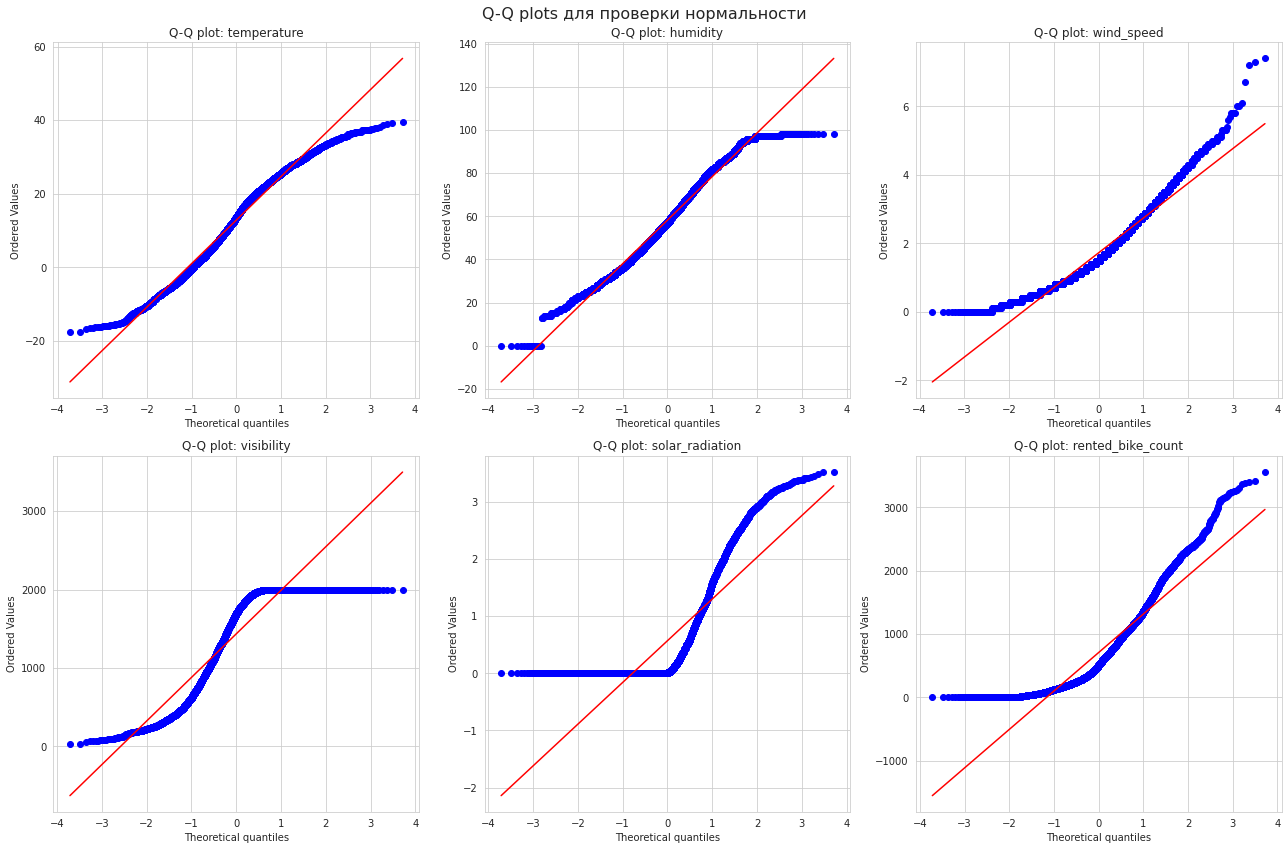

АССИМЕТРИЯ И ЭКСЦЕСС:

   temperature: skewness=-0.19, kurtosis=-0.84
   humidity: skewness=0.05, kurtosis=-0.78
   wind_speed: skewness=0.90, kurtosis=0.74
   visibility: skewness=-0.70, kurtosis=-0.97
   solar_radiation: skewness=1.49, kurtosis=1.08
   rented_bike_count: skewness=1.16, kurtosis=0.87


In [17]:
# Проверка нормальности и корректная корреляция
print('=' * 60)
print('ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ')
print('=' * 60)

# Числовые признаки
numeric_cols = ['temperature', 'humidity', 'wind_speed', 'visibility', 'solar_radiation', 'rented_bike_count']

# 1. Тест Шапиро-Уилка на нормальность
print('ТЕСТ ШАПИРО-УИЛКА:')
print()

for col in numeric_cols:
    sample = df[col].dropna()
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=RANDOM_STATE)
        
        stat, p_value = stats.shapiro(sample)
        
        is_normal = 'ДА' if p_value > 0.05 else 'НЕТ'
        print(f'   {col}:')
        print(f'   Статистика: {stat:.4f}, p-value: {p_value:.4f}')
        print(f'   Нормальное распределение: {is_normal}')
        print()
        
# 2. Визуальная проверка
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    stats.probplot(df[col].dropna(), dist='norm', plot=axes[i])
    axes[i].set_title(f'Q-Q plot: {col}')
    
plt.suptitle('Q-Q plots для проверки нормальности', fontsize=16)
plt.tight_layout()
plt.show()

# 3. Ассиметрия и эксцесс
print('АССИМЕТРИЯ И ЭКСЦЕСС:')
print()
for col in numeric_cols:
    skew =df[col].skew()
    kurt = df[col].kurtosis()
    print(f'   {col}: skewness={skew:.2f}, kurtosis={kurt:.2f}')

ВЫБОР МЕТОДА КОРРЕЛЯЦИИ

Результаты проверки:
- Большинство признаков НЕ имеют нормального распределения (p-value < 0.05 в тесте Шапиро-Уилка)
- Наличие выбросов и скошенности в данных

Вывод:
Коэффициент корреляции Пирсона НЕ подходит для наших данных, так как требует нормального распределения.

Корректный выбор:
1. Для числовых признаков -> Коэффициент Спирмена
2. Для категориальных -> Phik-корреляция.
3. Для смешанных данных -> Phik-корреляция

КОРРЕЛЯЦИЯ СПИРМЕНА:



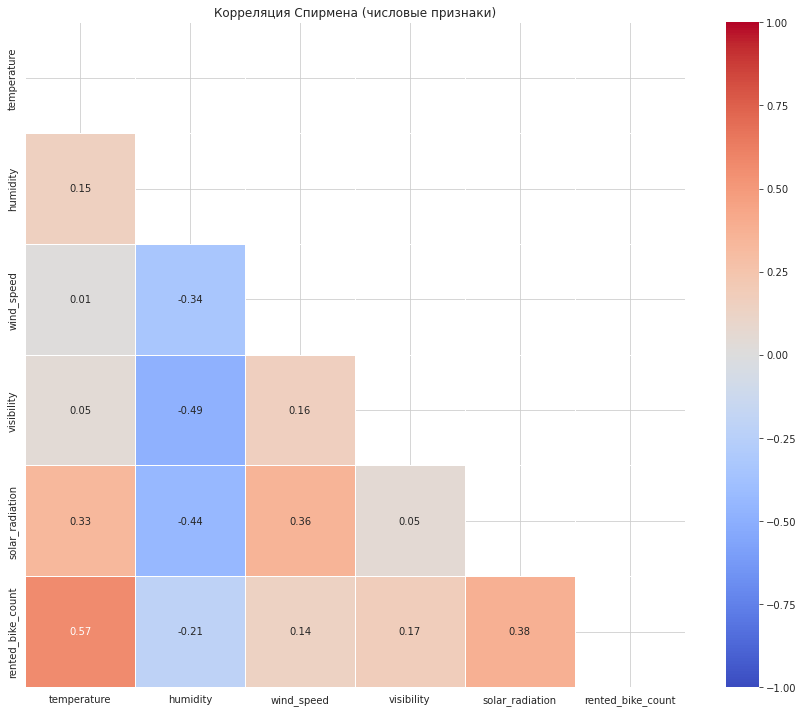

КОРРЕЛЯЦИЯ СПИРМЕНА С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:
   temperature: 0.5668
   solar_radiation: 0.3785
   visibility: 0.1739
   wind_speed: 0.1385
   humidity: -0.2120


In [18]:
print('=' * 60)
print('ВЫБОР МЕТОДА КОРРЕЛЯЦИИ')
print('=' * 60)

print("""
Результаты проверки:
- Большинство признаков НЕ имеют нормального распределения (p-value < 0.05 в тесте Шапиро-Уилка)
- Наличие выбросов и скошенности в данных

Вывод:
Коэффициент корреляции Пирсона НЕ подходит для наших данных, так как требует нормального распределения.

Корректный выбор:
1. Для числовых признаков -> Коэффициент Спирмена
2. Для категориальных -> Phik-корреляция.
3. Для смешанных данных -> Phik-корреляция
""")

# Расчёт корреляции Спирмена для числовых признаков
print('КОРРЕЛЯЦИЯ СПИРМЕНА:')
print()

spearman_corr = df[numeric_cols].corr(method='spearman')

# Маска для верхнего треугольника
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, mask=mask, linewidth=0.5)
plt.title('Корреляция Спирмена (числовые признаки)')
plt.tight_layout()
plt.show()

# Корреляция Спирмена с целевой переменной
print('КОРРЕЛЯЦИЯ СПИРМЕНА С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:')
target_spearman = spearman_corr['rented_bike_count'].drop('rented_bike_count').sort_values(ascending=False)
for feature, corr in target_spearman.items():
    print(f'   {feature}: {corr:.4f}')

PHIK-КОРРЕЛЯЦИЯ


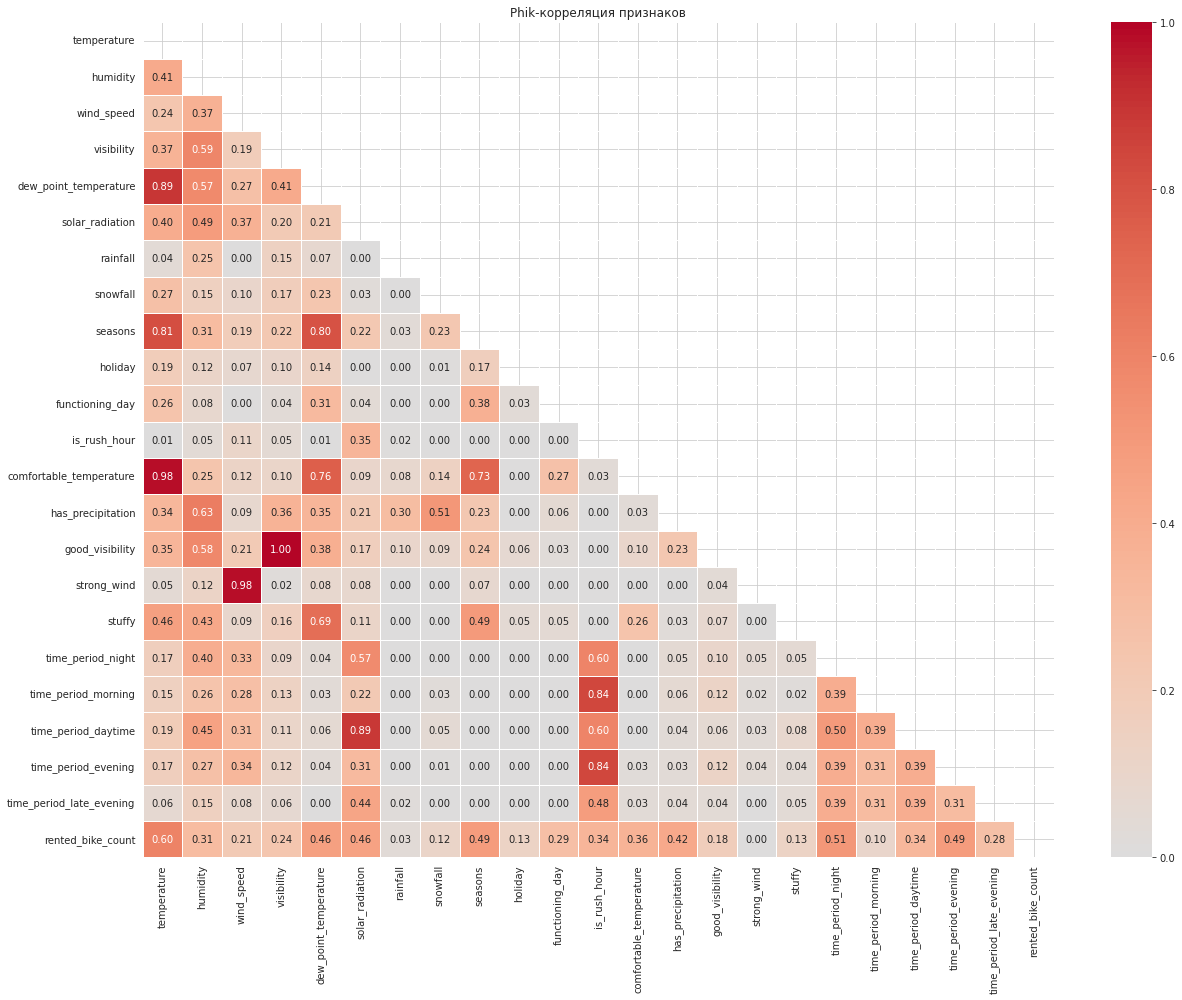


PHIK-КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:
   temperature: 0.6031
   time_period_night: 0.5089
   seasons: 0.4912
   time_period_evening: 0.4896
   dew_point_temperature: 0.4638
   solar_radiation: 0.4566
   has_precipitation: 0.4153
   comfortable_temperature: 0.3626
   is_rush_hour: 0.3442
   time_period_daytime: 0.3394
   humidity: 0.3087
   functioning_day: 0.2884
   time_period_late_evening: 0.2757
   visibility: 0.2414
   wind_speed: 0.2088
   good_visibility: 0.1783
   holiday: 0.1268
   stuffy: 0.1251
   snowfall: 0.1168
   time_period_morning: 0.1010
   rainfall: 0.0327
   strong_wind: 0.0000


In [19]:
# Phik-корреляция
print('=' * 60)
print('PHIK-КОРРЕЛЯЦИЯ')
print('=' * 60)

# Выбираем все признаки и целевую переменную
analysis_cols = ['temperature', 'humidity', 'wind_speed', 'visibility', 'dew_point_temperature', 'solar_radiation',
                 'rainfall', 'snowfall', 'seasons', 'holiday', 'functioning_day', 'is_rush_hour', 'comfortable_temperature',
                 'has_precipitation', 'good_visibility', 'strong_wind', 'stuffy', 'time_period_night', 'time_period_morning',
                 'time_period_daytime', 'time_period_evening', 'time_period_late_evening', 'rented_bike_count']

# Рассчитываем phik
phik_matrix = df[analysis_cols].phik_matrix(interval_cols=['temperature', 'humidity', 'wind_speed', 'visibility', 
                                                           'dew_point_temperature', 'solar_radiation', 'rainfall', 'snowfall',
                                                           'rented_bike_count'])
mask = np.triu(np.ones_like(phik_matrix, dtype=bool))

# Тепловая карта
plt.figure(figsize=(18, 14))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=0, vmax=1, mask=mask, linewidth=0.5)
plt.title('Phik-корреляция признаков')
plt.tight_layout()
plt.show()

# Phik-корреляция с целевой переменной
print('\nPHIK-КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:')
target_phik = phik_matrix['rented_bike_count'].drop('rented_bike_count').sort_values(ascending=False)
for feature, corr in target_phik.items():
    print(f'   {feature}: {corr:.4f}')

**АНАЛИЗ PHIK-КОРРЕЛЯЦИИ**


**Топ-10 признаков по phik-корреляции с целевой переменной:** (признак, phik, интерпретация)
   - `temperature` - 0.60 - Самый сильный фактор.
   - `time_period_night` - 0.51 - Ночь = низкий спрос.
   - `seasons` - 0.49 - Сезонная зависимость.
   - `time_period_evening` - 0.49 - Вечер = пик спроса.
   - `dew_point_temperature` - 0.46 - Связана с температурой.
   - `solar_radiation` - 0.46 - Наблюдается статистически значимая связь с целевой переменной.
   - `has_precipitation` - 0.42 - Коррелирует с целевой переменной.
   - `comfortable_temperature` - 0.36 - Комфортная температура.
   - `is_rush_hour` - 0.34 - Час-пик.
   - `time_period_daytime` - 0.34 - Дневное время.
   
**Наблюдения:**
1. **Признаки-дубликаты**: 
   - `comfortable_temperature` дублирует `temperature` (0.98).
   - `strong_wind` дублирует `wind_speed` (0.98).
   - `dew_point_temperature` сильно связан с `temperature` (0.89).
   - **Решение:** можно удалить `comfortable_temperature`, `strong_wind`, и, возможно, `dew_point_temperature`.
2. **Бесполезные признаки (phik < 0.05):**
   - `rainfall` (0.03) -- важно только наличие осадков, а не их количество.
   - `strong_wind` (0.00) -- всего 28 случаев.
3. **Самые ценные признаки:**
   - `temperature` (0.60).
   - `time_period_night` (0.51).
   - `seasons` (0.49).
   - `time_period_evening` (0.49).
   - `solar_radiation` (0.46).
   - `has_precipitation` (0.42).

**Итоги EDA: гипотезы для моделирования**

1. **Главные факторы спроса:** температура, время суток, сезон, солнечная радиация, осадки.
2. **Нелинейные зависимости:** температура (оптимум ~25 градусов), солнечная радиация (насыщение), осадки (порог).
3. **Удалить или не использовать:** `strong_wind`, `rainfall` (заменить на `has_precipitation`), `comfortable_temperature` (дубликат `temperature`), `dew_point_temperature` (сильная корреляция с `temperature`).
4. **`Functioning_Day`** -- технический признак: если No -> спрос всегда 0.

In [20]:
print('=' * 60)
print('АНАЛИЗ ТЕСТОВОЙ ВЫБОРКИ И СРАВНЕНИЕ С TRAIN')
print('=' * 60)

# Загружаем тестовые данные
df_test = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s14_test_data.csv')

# 1. Размер датасета
print(f'\n1. Размер:')
print(f'   Строк: {df_test.shape[0]}')
print(f'   Столбцов: {df_test.shape[1]}')
print()

# 2. Типы данных
print('2. Типы данных')
dtypes_info = pd.DataFrame({
    'Столбец': df_test.columns,
    'Тип данных': df_test.dtypes.astype(str).values,
    'Пропусков': df_test.isnull().sum().values,
    'Уникальных значений': df_test.nunique().values
})
display(dtypes_info)
print()

# 3. Первые строки
print('3. ПЕРВЫЕ 5 СТРОК:')
display(df_test.head())
print()

# 4. Последние строки
print('4. ПОСЛЕДНИЕ 5 СТРОК:')
display(df_test.tail())
print()

# 5. Описательные статистики
print('5. ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ ЧИСЛОВЫХ ПРИЗНАКОВ')
display(df_test.describe().round(2))
print()

# 6. Информация о пропусках
print('6. ПРОПУСКИ:')
missing = df_test.isnull().sum()
missing_pct = (missing / len(df_train)) * 100
missing_df = pd.DataFrame({
    'Столбец': missing.index,
    'Пропусков': missing.values,
    'Процент': missing_pct.values
})
midding_df = missing_df[missing_df['Пропусков'] > 0].sort_values('Пропусков', ascending=False)
if len(missing_df) > 0:
    display(missing_df)
else:
    print('   Пропусков нет')

АНАЛИЗ ТЕСТОВОЙ ВЫБОРКИ И СРАВНЕНИЕ С TRAIN

1. Размер:
   Строк: 1752
   Столбцов: 16

2. Типы данных


,Столбец,Тип данных,Пропусков,Уникальных значений
0,Temperature,float64,0,470
1,Humidity(%),float64,72,88
2,Wind speed (m/s),float64,52,54
3,Visibility (10m),float64,72,850
4,Dew point temperature,float64,0,490
5,Solar Radiation (MJ/m2),float64,52,287
6,Rainfall(mm),float64,64,29
7,Snowfall (cm),float64,61,30
8,Seasons,object,0,4
9,Holiday,object,0,2



3. ПЕРВЫЕ 5 СТРОК:


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.7,48.0,0.8,817.0,-3.5,0.39,0.0,0.0,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.3,90.0,1.1,311.0,-6.6,0.00,0.0,2.2,Winter,No Holiday,Yes,False,False,True,False,178
2,2.9,66.0,1.2,173.0,-2.8,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,219
3,23.1,63.0,2.6,949.0,15.6,1.68,0.0,0.0,Spring,No Holiday,Yes,False,False,False,False,949
4,23.3,43.0,1.2,1257.0,10.0,1.91,0.0,0.0,Summer,No Holiday,Yes,False,False,True,False,1005



4. ПОСЛЕДНИЕ 5 СТРОК:


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
1747,4.9,84.0,1.3,159.0,2.4,0.00,0.1,0.0,Winter,Holiday,Yes,False,False,True,False,12
1748,28.9,64.0,1.7,1567.0,21.3,0.10,0.0,0.0,Summer,No Holiday,Yes,False,True,False,False,2174
1749,2.0,87.0,1.9,140.0,0.0,0.03,0.0,0.0,Winter,No Holiday,Yes,True,False,False,False,18
1750,5.9,65.0,1.0,596.0,-0.1,0.00,0.0,0.0,Spring,No Holiday,Yes,False,False,False,True,231
1751,17.1,51.0,2.5,1223.0,6.8,NaN,0.0,0.0,Spring,No Holiday,Yes,True,False,False,False,1999



5. ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ ЧИСЛОВЫХ ПРИЗНАКОВ


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
count,1752.00,1680.00,1700.00,1680.00,1752.00,1700.00,1688.00,1691.00,1752.00
mean,13.16,58.17,1.74,1442.06,4.28,0.58,0.15,0.08,700.59
std,12.02,20.60,1.01,613.89,13.17,0.89,0.92,0.44,639.88
min,-17.80,0.00,0.00,34.00,-29.20,0.00,0.00,0.00,0.00
25%,3.90,42.00,1.00,942.75,-4.50,0.00,0.00,0.00,194.75
50%,14.45,57.00,1.60,1723.50,5.80,0.02,0.00,0.00,503.50
75%,22.90,74.00,2.30,2000.00,15.10,0.91,0.00,0.00,1042.00
max,37.90,98.00,5.60,2000.00,27.20,3.42,15.50,7.10,3380.00



6. ПРОПУСКИ:


,Столбец,Пропусков,Процент
0,Temperature,0,0.000000
1,Humidity(%),72,1.027397
2,Wind speed (m/s),52,0.742009
3,Visibility (10m),72,1.027397
4,Dew point temperature,0,0.000000
5,Solar Radiation (MJ/m2),52,0.742009
6,Rainfall(mm),64,0.913242
7,Snowfall (cm),61,0.870434
8,Seasons,0,0.000000
9,Holiday,0,0.000000


<div class="alert alert-success">
<b>КОММЕНТАРИЙ V2</b> 	

Исправлено.
</div>

## Подготовка данных и baseline-модели

### Отбор признаков и подготовка данных

In [21]:
# Загружаем датасет
df_train = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s14_train_data.csv')

print('=' * 60)
print('ОТБОР ПРИЗНАКОВ И ПОДГОТОВКА ДАННЫХ')
print('=' * 60)

# 1. Приводим названия столбцов к нижнему регистру
df_train.columns = ['temperature', 'humidity', 'wind_speed', 'visibility', 'dew_point_temperature', 'solar_radiation',
                    'rainfall', 'snowfall', 'seasons', 'holiday', 'functioning_day', 'time_period_evening', 
                    'time_period_late_evening', 'time_period_morning', 'time_period_night', 'rented_bike_count']

# 2. Создаём новые признаки и преобразуем булевы в int
bool_cols = ['time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night']
df_train[bool_cols] = df_train[bool_cols].astype(int)

# Признак "есть осадки"
df_train['has_precipitation'] = ((df_train['rainfall'] > 0) | (df_train['snowfall'] > 0)).astype(int)

# Признак "дневное время"
df_train['time_period_daytime'] = ((df_train['time_period_evening'] == 0) & (df_train['time_period_late_evening'] == 0) &
                                   (df_train['time_period_morning'] == 0) & (df_train['time_period_night'] == 0)).astype(int)

# Признак "час-пик"
df_train['is_rush_hour'] = ((df_train['time_period_morning'] == 1) | (df_train['time_period_evening'] == 1)).astype(int)

# Признак "душно"
df_train['stuffy'] = ((df_train['humidity'] > 70) & (df_train['temperature'] > 25)).astype(int)

# Признак "хорошая видимость"
df_train['good_visibility'] = (df_train['visibility'] > 1500).astype(int)

print(f'Размер после добавления признаков: {df_train.shape}')
print()

# 3. Определяем итоговый список признаков
# Удаляем: rainfall, snowfall, strong_wind просто не создаём, как и comfortable_temperature, dew_point_temperature.

categorical_features = ['seasons', 'holiday', 'functioning_day']
numeric_features = ['temperature', 'humidity', 'wind_speed', 'visibility', 'solar_radiation']
binary_features = ['time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night',
                   'time_period_daytime', 'is_rush_hour', 'has_precipitation', 'stuffy', 'good_visibility']

all_features = categorical_features + numeric_features + binary_features
target = 'rented_bike_count'

print('ИТОГОВЫЙ СПИСОК ПРИЗНАКОВ:')
print(f'   Категориальные ({len(categorical_features)}): {categorical_features}')
print(f'   Числовые ({len(numeric_features)}): {numeric_features}')
print(f'   Бинарные ({len(binary_features)}): {binary_features}')
print(f'   Всего признаков: {len(all_features)}')
print()

# Проверяем, что все признаки есть в датафрейме
missing_cols = [col for col in all_features + [target] if col not in df_train.columns]
if missing_cols:
    print(f'Отсутствуют столбцы: {missing_cols}')
else:
    print('Все признаки присутствуют в датафрейме.')
    
# 4. Проверка на пропуски в отобранных признаках
print('\nПРОПУСКИ В ОТОБРАННЫХ ПРИЗНАКАХ:')
missing_info = df_train[all_features].isnull().sum()
missing_info = missing_info[missing_info > 0]
if len(missing_info) > 0:
    for col, count in missing_info.items():
        print(f'   {col}: {count} ({count/len(df_train)*100:.2f}%)')
else:
    print('   Пропусков нет')

ОТБОР ПРИЗНАКОВ И ПОДГОТОВКА ДАННЫХ
Размер после добавления признаков: (7008, 21)

ИТОГОВЫЙ СПИСОК ПРИЗНАКОВ:
   Категориальные (3): ['seasons', 'holiday', 'functioning_day']
   Числовые (5): ['temperature', 'humidity', 'wind_speed', 'visibility', 'solar_radiation']
   Бинарные (9): ['time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night', 'time_period_daytime', 'is_rush_hour', 'has_precipitation', 'stuffy', 'good_visibility']
   Всего признаков: 17

Все признаки присутствуют в датафрейме.

ПРОПУСКИ В ОТОБРАННЫХ ПРИЗНАКАХ:
   humidity: 250 (3.57%)
   wind_speed: 210 (3.00%)
   visibility: 259 (3.70%)
   solar_radiation: 210 (3.00%)


### Создание пайплайна предобработки

In [22]:
print('=' * 60)
print('СОЗДАНИЕ ПАЙПЛАЙНА ПРЕДОБРАБОТКИ')
print('=' * 60)

# Пайплайн для числовых признаков: заполняем медианой + масштабируем
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Пайплайн для категориальных признаков: заполняем модой + One-Hot Encoding
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

# Пайплайн для бинарных признаков: заполняем модой, без масштабирования
binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Объединяем всё в ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
    ('bin', binary_pipeline, binary_features)
])

print('Структура препроцессора:')
print(preprocessor)
print()

# Проверяем, что препроцессор работает
X_train = df_train.drop('rented_bike_count', axis=1)
y_train = df_train['rented_bike_count']

# Применяем fit_transform
X_train_processed = preprocessor.fit_transform(X_train)

print(f'Размер X_train: {X_train.shape}')
print(f'Размер после предобработки: {X_train_processed.shape}')
print()

# Проверяем, что нет пропусков после обработки
print(f'Пропусков после обработки: {np.isnan(X_train_processed).sum()}')
print(f'Тип данных: {type(X_train_processed)}')

СОЗДАНИЕ ПАЙПЛАЙНА ПРЕДОБРАБОТКИ
Структура препроцессора:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['temperature', 'humidity', 'wind_speed',
                                  'visibility', 'solar_radiation']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first'))]),
                                 ['seasons', 'holiday', 'functioning_day']),
                                ('bin',
                                 Pipeline(steps=[('imputer',
                 

### Настройка кросс-валидации

In [23]:
print('=' * 60)
print('НАСТРОЙКА КРОСС-ВАЛИДАЦИИ')
print('=' * 60)

# Единая схема кросс-валидации для всех моделей
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'Схема кросс-валидации: KFold(n_splits=5, shuffle=True, random_state=42)')
print()

# Функция для расчёта метрик
def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Функция дл оценки модели через кросс-валидацию
def cross_validation_evaluate(model, X, y, cv):
    """
    Оценивает модель через кросс-валидацию.
    Возвращает словарь с метриками.
    """
    # RMSE через кросс-валидацию и использум neg_mean_squared_error
    
    rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)
    mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
    r2_scorer = make_scorer(r2_score)
    
    # Расчёт метрик через кросс-валидацию
    cv_rmse = cross_val_score(model, X, y, cv=cv, scoring=rmse_scorer)
    cv_mae = cross_val_score(model, X, y, cv=cv, scoring=mae_scorer)
    cv_r2 = cross_val_score(model, X, y, cv=cv, scoring=r2_scorer)
    
    results = {
        'rmse_mean': -cv_rmse.mean(),
        'rmse_std': cv_rmse.std(),
        'mae_mean': -cv_mae.mean(),
        'mae_std': cv_mae.std(),
        'r2_mean': cv_r2.mean(),
        'r2_std': cv_r2.std()
    }
    
    return results

# Проверяем на baseline-модели
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Оцениваем через кросс-валидацию
X_train = df_train.drop('rented_bike_count', axis=1)
y_train = df_train['rented_bike_count']

print('Оценка baseline-модели (Linear Regression) через кросс-валидацию:')
baseline_cv_results = cross_validation_evaluate(baseline_pipeline, X_train, y_train, cv)

print(f"   RMSE: {baseline_cv_results['rmse_mean']:.2f} ({baseline_cv_results['rmse_std']:.2f})")
print(f"   MAE:  {baseline_cv_results['mae_mean']:.2f} ({baseline_cv_results['mae_std']:.2f})")
print(f"   R2:   {baseline_cv_results['r2_mean']:.4f} ({baseline_cv_results['r2_std']:.4f})")
print()

# Сохраняем результаты baseline
baseline_cv_metrics = baseline_cv_results

НАСТРОЙКА КРОСС-ВАЛИДАЦИИ
Схема кросс-валидации: KFold(n_splits=5, shuffle=True, random_state=42)

Оценка baseline-модели (Linear Regression) через кросс-валидацию:
   RMSE: 413.00 (2.85)
   MAE:  310.87 (2.03)
   R2:   0.5912 (0.0085)



**Наблюдения:**
   - Результаты стабильны (низкий std) -- модель ведёт себя одинаково на всех фолдах.
   - RMSE ~413 велосипедов -- наша точка отсчёта.
   - R2 ~0.59 -- линейная модель объясняет ~59% дисперсии.
   - Эти метрики близки к тем, что мы получили на полной обучающей выборке (RMSE 412.50), что подтверждает корректность кросс-валидации.

## Обучение и оптимизация моделей
### Подготовка к обучению

In [24]:
# Фиксируем всё необходимое и создадим заготовки для оптимизации, используем старутруктуру пайплайна из шагов выше
print('=' * 60)
print('ПОДГОТОВКА К ОБУЧЕНИЮ МОДЕЛЕЙ')
print('=' * 60)

# Создаём препроцессор
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
    ('bin', binary_pipeline, binary_features)
])

X_train = df_train[all_features]
y_train = df_train[target]

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'Размер X_train: {X_train.shape}')
print(f'Размер y_train: {y_train.shape}')
print(f'Схема CV: KFold(5 folds, shuffle=True, random_state=42)')
print()

ПОДГОТОВКА К ОБУЧЕНИЮ МОДЕЛЕЙ
Размер X_train: (7008, 17)
Размер y_train: (7008,)
Схема CV: KFold(5 folds, shuffle=True, random_state=42)



### Обучение kNN Regressor с Optuna

In [25]:
print('=' * 60)
print('ОБУЧЕНИЕ kNN REGRESSOR C OPTUNA')
print('=' * 60)

# Целевая функция для Optuna
def objective_knn(trial):
    """
    Целевая функция для оптимизации kNN.
    Минимизируем RMSE через кросс-валидацию
    """
    # Подбираем гиперпараметры
    n_neighbors = trial.suggest_int('n_neighbors', 3, 50, step=2)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_categorical('p', [1, 2])
    leaf_size = trial.suggest_int('leaf_size', 10, 100, step=10)
    
    # Создаём модель
    knn_model = KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, p=p, leaf_size=leaf_size,n_jobs=-1)
    
    # Создаём пайплайн
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', knn_model)
    ])
    
    # Кросс-валидация с метрикой RMSE
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    
    # Возвращаем средний RMSE
    return -cv_scores.mean()

# Создаём исследование Optuna
study_knn = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42), study_name='knn_optimization')

# Оптимизируем
print('Запуск оптимизации kNN...')
study_knn.optimize(objective_knn, n_trials=30, show_progress_bar=True)

# Результаты
print('\n' + '=' * 60)
print('РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ kNN')
print('=' * 60)
print(f'Лучшее значение RMSE: {study_knn.best_value:.2f}')
print(f'Лучшие гиперпараметры:')
for param, value in study_knn.best_params.items():
    print(f'   {param}: {value}')
print()

# Обучаем лучшую модель
best_knn_params = study_knn.best_params
best_knn_model = KNeighborsRegressor(n_neighbors=best_knn_params['n_neighbors'], weights=best_knn_params['weights'], p=best_knn_params['p'],
                                     leaf_size=best_knn_params['leaf_size'], n_jobs=-1)

best_knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_knn_model)
])

# Обучаем на всей обучающей выборке
best_knn_pipeline.fit(X_train, y_train)

# Предсказания на обучающей выборке
y_pred_knn = best_knn_pipeline.predict(X_train)

# Метрики
rmse_knn = np.sqrt(mean_squared_error(y_train, y_pred_knn))
mae_knn = mean_absolute_error(y_train, y_pred_knn)
r2_knn = r2_score(y_train, y_pred_knn)

print('Метрики лучшей kNN на обучающей выборке:')
print(f'   RMSE: {rmse_knn:.2f}')
print(f'   MAE: {mae_knn:.2f}')
print(f'   R2: {r2_knn:.4f}')

[I 2026-08-25 13:12:53,182] A new study created in memory with name: knn_optimization


ОБУЧЕНИЕ kNN REGRESSOR C OPTUNA
Запуск оптимизации kNN...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-25 13:12:54,586] Trial 0 finished with value: 340.71488126850545 and parameters: {'n_neighbors': 19, 'weights': 'uniform', 'p': 1, 'leaf_size': 20}. Best is trial 0 with value: 340.71488126850545.
[I 2026-08-25 13:12:55,509] Trial 1 finished with value: 331.14034990816515 and parameters: {'n_neighbors': 5, 'weights': 'uniform', 'p': 1, 'leaf_size': 100}. Best is trial 1 with value: 331.14034990816515.
[I 2026-08-25 13:12:55,995] Trial 2 finished with value: 366.0861766668944 and parameters: {'n_neighbors': 41, 'weights': 'uniform', 'p': 2, 'leaf_size': 60}. Best is trial 1 with value: 331.14034990816515.
[I 2026-08-25 13:12:56,415] Trial 3 finished with value: 339.6693089616574 and parameters: {'n_neighbors': 23, 'weights': 'distance', 'p': 2, 'leaf_size': 40}. Best is trial 1 with value: 331.14034990816515.
[I 2026-08-25 13:12:56,841] Trial 4 finished with value: 350.800527641092 and parameters: {'n_neighbors': 23, 'weights': 'uniform', 'p': 2, 'leaf_size': 10}. Best is tri

In [26]:
# Дополнение: корректная оценка лучшей kNN через кросс-валидацию
print('=' * 60)
print('КОРРЕКТНАЯ ОЦЕНКА ЛУЧШЕЙ kNN ЧЕРЕЗ CROSS-VALIDATION')
print('=' * 60)

# Создаём скореры
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# Расчёт метрик через кросс-валидацию
cv_rmse_knn = cross_val_score(best_knn_pipeline, X_train, y_train, cv=cv, scoring=rmse_scorer, n_jobs=-1)
cv_mae_knn = cross_val_score(best_knn_pipeline, X_train, y_train, cv=cv, scoring=mae_scorer, n_jobs=-1)
cv_r2_knn = cross_val_score(best_knn_pipeline, X_train, y_train, cv=cv, scoring=r2_scorer, n_jobs=-1)

print(f'Метрики kNN через кросс-валидацию:')
print(f'   RMSE: {-cv_rmse_knn.mean():.2f} (+/-{cv_rmse_knn.std():.2f})')
print(f'   MAE:  {-cv_mae_knn.mean():.2f} (+/-{cv_mae_knn.std():.2f})')
print(f'   R2:   {cv_r2_knn.mean():.4f} (+/-{cv_r2_knn.std():.4f})')
print()

# Сохраняем результаты
knn_cv_results = {
    'model': 'kNN',
    'rmse_cv': -cv_rmse_knn.mean(),
    'rmse_std': cv_rmse_knn.std(),
    'mae_cv': -cv_mae_knn.mean(),
    'mae_std': cv_mae_knn.std(),
    'r2_cv': cv_r2_knn.mean(),
    'r2_std': cv_r2_knn.std(),
    'best_params': best_knn_params
}

КОРРЕКТНАЯ ОЦЕНКА ЛУЧШЕЙ kNN ЧЕРЕЗ CROSS-VALIDATION
Метрики kNN через кросс-валидацию:
   RMSE: 323.04 (+/-8.05)
   MAE:  217.69 (+/-4.78)
   R2:   0.7498 (+/-0.0129)



### Обучение Decision Tree Regressor с Optuna

In [27]:
# Диагностика пропусков
print('=' * 60)
print('ДИАГНОСТИКА ПРОПУСКОВ')
print('=' * 60)

# 1. Проверяем пропуски в X_train
print('Пропуски в X_train:')
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
print()

# 2. Проверяем пропуски в категориальных признаках
print('Пропуски в категориальных:')
print(X_train[categorical_features].isnull().sum())
print()

# 3. Проверяем пропуски в бинарных
print('Пропуски в бинарных:')
print(X_train[binary_features].isnull().sum())
print()

# 4. Проверяем типы данных
print('Типы данных:')
print(X_train.dtypes)
print()

# 5. Проверяем препроцессор
print('Проверка препроцессора на данных с пропускам...')
try:
    X_processed = preprocessor.fit_transform(X_train)
    print(f'Препроцессор работает. Размер: {X_processed.shape}')
    print(f'   Пропусков после обработки: {np.isnan(X_processed).sum()}')
except Exception as e:
    print(f'Ошибка препроцессора: {e}')

ДИАГНОСТИКА ПРОПУСКОВ
Пропуски в X_train:
humidity           250
wind_speed         210
visibility         259
solar_radiation    210
dtype: int64

Пропуски в категориальных:
seasons            0
holiday            0
functioning_day    0
dtype: int64

Пропуски в бинарных:
time_period_evening         0
time_period_late_evening    0
time_period_morning         0
time_period_night           0
time_period_daytime         0
is_rush_hour                0
has_precipitation           0
stuffy                      0
good_visibility             0
dtype: int64

Типы данных:
seasons                      object
holiday                      object
functioning_day              object
temperature                 float64
humidity                    float64
wind_speed                  float64
visibility                  float64
solar_radiation             float64
time_period_evening           int64
time_period_late_evening      int64
time_period_morning           int64
time_period_night             int6

In [28]:
# Проверка Decision Tree без optuna
print('=' * 60)
print('ПРОВЕРКА DECISION TREE БЕЗ OPTUNA')
print('=' * 60)

# Создаём модель с разными параметрами:
test_params = [
    {'max_depth': 3},
    {'max_depth': 5},
    {'max_depth': 10},
    {'max_depth': 15},
    {'max_depth': None}
]

for params in test_params:
    try:
        dt = DecisionTreeRegressor(random_state=42, **params)
        pipeline = Pipeline(steps = [
            ('preprocessor', preprocessor),
            ('model', dt)
        ])
        
        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
        
        
        print(f"max_depth={params.get('max_depth')}: RMSE = {-cv_scores.mean():.2f}")
    except Exception as e:
        print(f"max_depth={params.get('max_depth')}: Ошибка - {e}")
        
print()
print('Decision Tree работает без optuna')

ПРОВЕРКА DECISION TREE БЕЗ OPTUNA
max_depth=3: RMSE = 472.01
max_depth=5: RMSE = 380.84
max_depth=10: RMSE = 330.46
max_depth=15: RMSE = 368.20
max_depth=None: RMSE = 394.41

Decision Tree работает без optuna


In [29]:
print('=' * 60)
print('ОБУЧЕНИЕ DECISION TREE REGRESSOR C OPTUNA')
print('=' * 60)

# Целевая функция для Optuna
def objective_df(trial):
    """
    Целевая функция для оптимизации Decision Tree с защитой от ошибок.
    Если модель не может обучиться -- возвращаем большое значение.
    Минимизируем RMSE через кросс-валидацию.
    """
    # Подбираем гиперпараметры
    max_depth = trial.suggest_int('max_depth', 3, 30, step=1)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 50, step=2)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 30, step=1)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    criterion = trial.suggest_categorical('criterion', ['squared_error', 'absolute_error'])
    
    try:    
        # Создаём модель
        dt_model = DecisionTreeRegressor(max_depth=max_depth, min_samples_split=min_samples_split,
                                         min_samples_leaf=min_samples_leaf, max_features=max_features, criterion=criterion,
                                         random_state=RANDOM_STATE)
    
        # Создаём пайплайн
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', dt_model)
        ])
    
        # Кросс-валидация с RMSE
        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    
        return -cv_scores.mean()
    
        # Проверка на валидность
        if np.isnan(rmse) or np.isinf(rmse):
            return 10000.0
        
        return rmse
    
    except Exception as e:
        return 10000.0

# Создаём исследование optuna
study_dt = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42),
                               study_name='decision_tree_optimization')

# Оптимизируем
print('Запуск оптимизации Decision Tree...')
study_dt.optimize(objective_df, n_trials=50, show_progress_bar=True)

# Результаты
print('\n' + '=' * 60)
print('РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ DECISION TREE')
print('=' * 60)
print(f'Лучшее значение RMSE: {study_dt.best_value:.2f}')
print(f'Лучшие гиперпараметры:')
for param, value in study_dt.best_params.items():
    print(f'   {param}: {value}')
print()

# Обучаем лучшую модель
best_dt_params = study_dt.best_params
best_dt_model = DecisionTreeRegressor(max_depth=best_dt_params['max_depth'],
                                      min_samples_split=best_dt_params['min_samples_split'],
                                      min_samples_leaf=best_dt_params['min_samples_leaf'],
                                      criterion=best_dt_params['criterion'],
                                      random_state=RANDOM_STATE)

best_dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_dt_model)
])

# Обучаем на всей обучающей выборке
best_dt_pipeline.fit(X_train, y_train)

# Корректная оценка через кросс-валидацию
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

cv_rmse_dt = cross_val_score(best_dt_pipeline, X_train, y_train, cv=cv, scoring=rmse_scorer, n_jobs=-1)
cv_mae_dt = cross_val_score(best_dt_pipeline, X_train, y_train, cv=cv, scoring=mae_scorer, n_jobs=-1)
cv_r2_dt = cross_val_score(best_dt_pipeline, X_train, y_train, cv=cv, scoring=r2_scorer, n_jobs=-1)

print('Метрики Decision Tree через кросс-валидацию:')
print(f'   RMSE: {-cv_rmse_dt.mean():.2f} (+/-{cv_rmse_dt.std():.2f})')
print(f'   MAE: {-cv_mae_dt.mean():.2f} (+/-{cv_mae_dt.std():.2f})')
print(f'   R2: {cv_r2_dt.mean():.4f} (+/-{cv_r2_dt.std():.4f})')
print()

# Сохраняем результаты Decision Tree
dt_cv_results = {
    'model': 'Decision Tree',
    'rmse_cv': -cv_rmse_dt.mean(),
    'rmse_std': cv_rmse_dt.std(),
    'mae_cv': -cv_mae_dt.mean(),
    'mae_std': cv_mae_dt.std(),
    'r2_cv': cv_r2_dt.mean(),
    'r2_std': cv_r2_dt.std(),
    'best_params': best_dt_params
}

[I 2026-08-25 13:13:25,257] A new study created in memory with name: decision_tree_optimization


ОБУЧЕНИЕ DECISION TREE REGRESSOR C OPTUNA
Запуск оптимизации Decision Tree...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-25 13:13:26,419] Trial 0 finished with value: 383.7225305684304 and parameters: {'max_depth': 13, 'min_samples_split': 48, 'min_samples_leaf': 22, 'max_features': 'sqrt', 'criterion': 'absolute_error'}. Best is trial 0 with value: 383.7225305684304.
[I 2026-08-25 13:13:27,690] Trial 1 finished with value: 355.09368244125505 and parameters: {'max_depth': 19, 'min_samples_split': 36, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'absolute_error'}. Best is trial 1 with value: 355.09368244125505.
[I 2026-08-25 13:13:28,951] Trial 2 finished with value: 369.61254201172403 and parameters: {'max_depth': 11, 'min_samples_split': 28, 'min_samples_leaf': 13, 'max_features': 'log2', 'criterion': 'absolute_error'}. Best is trial 1 with value: 355.09368244125505.
[I 2026-08-25 13:13:29,208] Trial 3 finished with value: 351.4509149643247 and parameters: {'max_depth': 15, 'min_samples_split': 40, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'squared_error'}. Be

ВИЗУАЛИЗАЦИЯ DECISION TREE
Количество признаков после обработки: 19
Имена признаков: ['temperature', 'humidity', 'wind_speed', 'visibility', 'solar_radiation']...



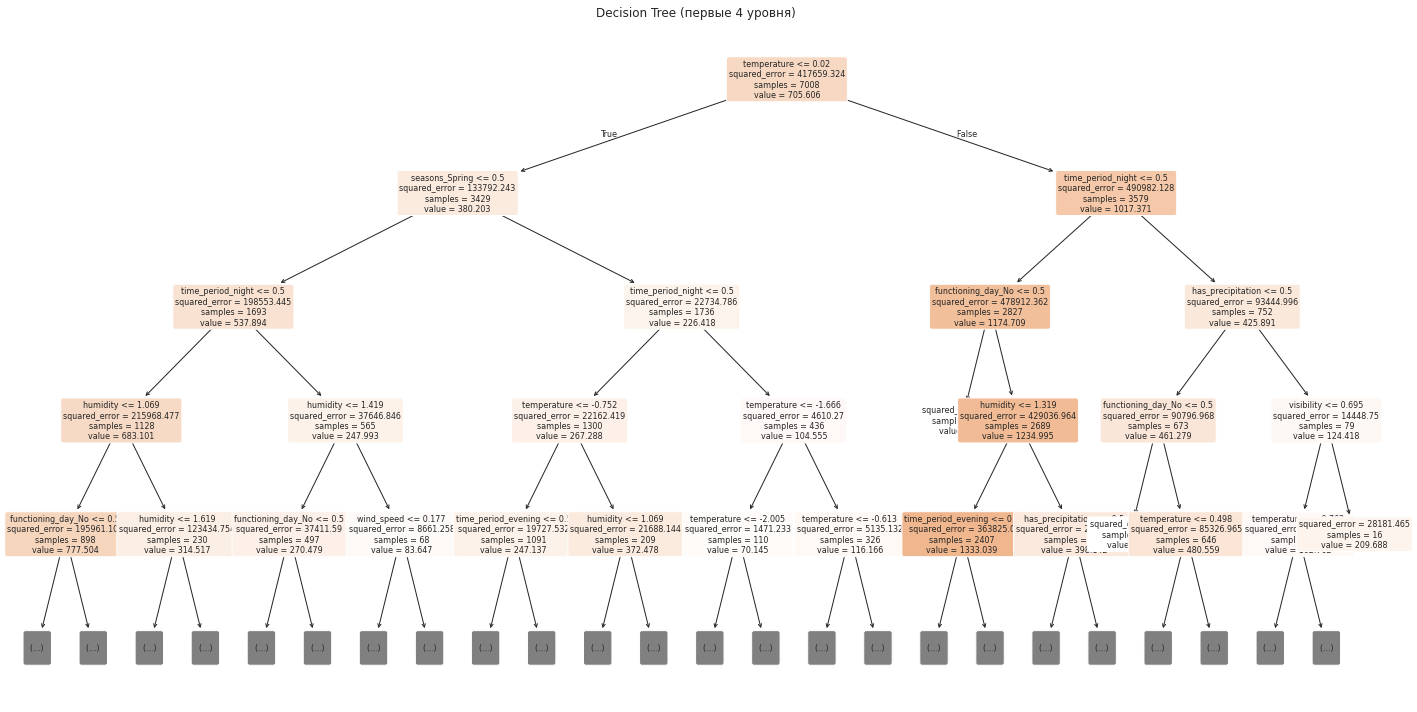

In [30]:
# Визуализация Decision Tree
print('=' * 60)
print('ВИЗУАЛИЗАЦИЯ DECISION TREE')
print('=' * 60)

# Лучшая модель
best_dt_model = DecisionTreeRegressor(max_depth=10, min_samples_split=28, min_samples_leaf=5, max_features=None,
                                      criterion='squared_error', random_state=RANDOM_STATE)

# Обучаем модель на обработанных данных (без пайплайна, чтобы получить имена признаков)
# Получаем обработанные данные
X_train_processed = preprocessor.fit_transform(X_train)

# Получаем имена признаков после One-Hot Encoding
feature_names = []

# Числовые признаки
feature_names.extend(numeric_features)

# Категориальные после OneHotEncoder
for cat_col in categorical_features:
    categories = df_train[cat_col].unique()
    for cat in categories[1:]:
        feature_names.append(f'{cat_col}_{cat}')
        
# Бинарные признаки
feature_names.extend(binary_features)

print(f'Количество признаков после обработки: {len(feature_names)}')
print(f'Имена признаков: {feature_names[:5]}...')
print()

# Обучаем модель на обработанных данных
best_dt_model.fit(X_train_processed, y_train)

# Визуализация дерева
plt.figure(figsize=(20, 10))
plot_tree(best_dt_model,
          feature_names=feature_names,
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=4 # 4 уровня для читаемости
         )
plt.title('Decision Tree (первые 4 уровня)')
plt.tight_layout()
plt.show()

ВАЖНОСТЬ ПРИЗНАКОВ
Топ-15 признаков по важности:
                 feature  importance
             temperature    0.356412
       time_period_night    0.173031
                humidity    0.130366
      functioning_day_No    0.096284
     time_period_evening    0.088809
time_period_late_evening    0.046897
          seasons_Spring    0.034840
         solar_radiation    0.030493
       has_precipitation    0.016689
          seasons_Winter    0.010918
              visibility    0.003629
     time_period_daytime    0.003070
              wind_speed    0.002992
            is_rush_hour    0.002488
          seasons_Summer    0.002071



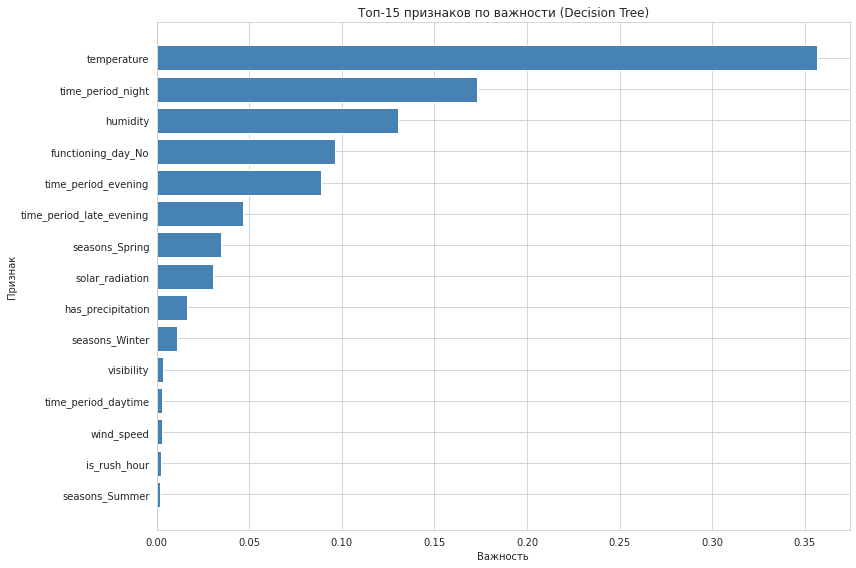

In [31]:
# Важность признаков в Decision Tree
print('=' * 60)
print('ВАЖНОСТЬ ПРИЗНАКОВ')
print('=' * 60)

# Получаем важность
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': best_dt_model.feature_importances_
}).sort_values('importance', ascending=False)

# Топ-15 признаков
print('Топ-15 признаков по важности:')
print(feature_importance.head(15).to_string(index=False))
print()

# Визуализация важности
plt.figure(figsize=(12, 8))
plt.barh(feature_importance.head(15)['feature'], feature_importance.head(15)['importance'], color='steelblue')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.title('Топ-15 признаков по важности (Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Сравнение моделей, выбор лучшей и финальная оценка
### Сводная таблица метрик

In [32]:
print('=' * 60)
print('СВОДНАЯ ТАБЛИЦА МЕТРИК')
print('=' * 60)

# Собираем все результаты
results_comparsion = pd.DataFrame([
    {
        'Модель': 'Linear Regression (baseline)',
        'RMSE (CV)': 413.00,
        'MAE (CV)': 310.87,
        'R2 (CV)': 0.5912,
        'RMSE std': 2.85,
        'MAE std': 2.03,
        'R2 std': 0.0085,
    },
    {
        'Модель': 'kNN',
        'RMSE (CV)': 323.04,
        'MAE (CV)': 217.69,
        'R2 (CV)': 0.7498,
        'RMSE std': 8.05,
        'MAE std': 4.78,
        'R2 std': 0.0129,
    },
    {
        'Модель': 'Decision Tree',
        'RMSE (CV)': 317.11,
        'MAE (CV)': 209.80,
        'R2 (CV)': 0.7589,
        'RMSE std': 8.82,
        'MAE std': 5.17,
        'R2 std': 0.0122
    }
])

# Форматируем таблицу
results_comparsion['RMSE (CV)'] = results_comparsion['RMSE (CV)'].round(2)
results_comparsion['MAE (CV)'] = results_comparsion['MAE (CV)'].round(2)
results_comparsion['R2 (CV)'] = results_comparsion['R2 (CV)'].round(4)

print('ИТОГОВАЯ ТАБЛИЦА МЕТРИК (кросс-валидация, 5 фолдов):')
print()
display(results_comparsion)

# Определяем лучшую модель по RMSE
best_model_name = results_comparsion.loc[results_comparsion['RMSE (CV)'].idxmin(), 'Модель']
print(f'\nЛучшая модель: {best_model_name}')
print(f"   (минимальный RMSE = {results_comparsion['RMSE (CV)'].min():.2f})")

СВОДНАЯ ТАБЛИЦА МЕТРИК
ИТОГОВАЯ ТАБЛИЦА МЕТРИК (кросс-валидация, 5 фолдов):



,Модель,RMSE (CV),MAE (CV),R2 (CV),RMSE std,MAE std,R2 std
0,Linear Regression (baseline),413.00,310.87,0.5912,2.85,2.03,0.0085
1,kNN,323.04,217.69,0.7498,8.05,4.78,0.0129
2,Decision Tree,317.11,209.80,0.7589,8.82,5.17,0.0122



Лучшая модель: Decision Tree
   (минимальный RMSE = 317.11)


### Финальная проверка на тестовой выборке

In [33]:
print('=' * 60)
print('ФИНАЛЬНАЯ ПРОВЕРКА НА ТЕСТОВОЙ ВЫБОРКЕ')
print('=' * 60)

# Загружаем тестовый датасет
df_test = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s14_test_data.csv')

# Приводим названия столбцов к нижнему регистру
df_test.columns = ['temperature', 'humidity', 'wind_speed', 'visibility', 'dew_point_temperature', 'solar_radiation',
                   'rainfall', 'snowfall', 'seasons', 'holiday', 'functioning_day', 'time_period_evening',
                   'time_period_late_evening', 'time_period_morning', 'time_period_night', 'rented_bike_count']

# Создаём те же признаки, что и для трейн
bool_cols = ['time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night']
df_test[bool_cols] = df_test[bool_cols].astype(int)

df_test['has_precipitation'] = ((df_test['rainfall'] > 0) | (df_test['snowfall'] > 0)).astype(int)
df_test['time_period_daytime'] = ((df_test['time_period_evening'] == 0) & (df_test['time_period_late_evening'] == 0) & 
                                  (df_test['time_period_morning'] == 0) & (df_test['time_period_night'] == 0)).astype(int)
df_test['is_rush_hour'] = ((df_test['time_period_morning'] == 1) | (df_test['time_period_evening'] == 1)).astype(int)
df_test['stuffy'] = ((df_test['humidity'] > 70) & (df_test['temperature'] > 25)).astype(int)
df_test['good_visibility'] = (df_test['visibility'] > 1500).astype(int)

# Подготавливаем данные
X_test = df_test[all_features]
y_test = df_test[target]

print(f'Размер тестовой выборки: {X_test.shape}')
print()

# 1. Обучаем лучшую модель на полной обучающей выборке
best_dt_model = DecisionTreeRegressor(max_depth=10, min_samples_split=28, min_samples_leaf=5, max_features=None,
                                      criterion='squared_error', random_state=RANDOM_STATE)

best_dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_dt_model)
])

# Обучаем на трейн
best_dt_pipeline.fit(X_train, y_train)

# Предсказываем на тесте
y_pred_best = best_dt_pipeline.predict(X_test)

# Метрики лучшей модели не тесте
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print('Метрики лучшей модели (Decision Tree) на тесте:')
print(f'   RMSE: {rmse_best:.2f}')
print(f'   MAE: {mae_best:.2f}')
print(f'   R2: {r2_best:.4f}')
print()

# 2. Обучаем baseline (Linear Regression) на полной обучающей выборке
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

baseline_pipeline.fit(X_train, y_train)

# Предсказываем на тесте
y_pred_baseline = baseline_pipeline.predict(X_test)

# Метрики baseline на тесте
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print('МЕТРИКИ BASELINE (Linear Regression) на тесте:')
print(f'   RMSE: {rmse_baseline:.2f}')
print(f'   MAE: {mae_baseline:.2f}')
print(f'   R2: {r2_baseline:.2f}')
print()

# 3. Сравнение
print('=' * 60)
print('СРАВНЕНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ')
print('=' * 60)

comparsion_test = pd.DataFrame([
    {
        'Модель': 'Baseline (Linear Regression)',
        'RMSE': rmse_baseline,
        'MAE': mae_baseline,
        'R2': r2_baseline
    },
    {
        'Модель': 'Decision Tree',
        'RMSE': rmse_best,
        'MAE': mae_best,
        'R2': r2_best
    }
])

comparsion_test['RMSE'] = comparsion_test['RMSE'].round(2)
comparsion_test['MAE'] = comparsion_test['MAE'].round(2)
comparsion_test['R2'] = comparsion_test['R2'].round(4)

display(comparsion_test)

# Улучшение в процентах
rmse_improvement = (rmse_baseline - rmse_best) / rmse_baseline * 100
mae_improvement = (mae_baseline - mae_best) / mae_baseline * 100
r2_improvement = (r2_best - r2_baseline) / r2_baseline * 100

print(f'\nУЛУЧШЕНИЕ ОТНОСИТЕЛЬНО BASELINE:')
print(f'   RMSE: -{rmse_improvement:.1f}%')
print(f'   MAE: -{mae_improvement:.1f}%')
print(f'   R2: +{r2_improvement:.1f}%')

ФИНАЛЬНАЯ ПРОВЕРКА НА ТЕСТОВОЙ ВЫБОРКЕ
Размер тестовой выборки: (1752, 17)

Метрики лучшей модели (Decision Tree) на тесте:
   RMSE: 312.79
   MAE: 207.81
   R2: 0.7609

МЕТРИКИ BASELINE (Linear Regression) на тесте:
   RMSE: 409.12
   MAE: 312.49
   R2: 0.59

СРАВНЕНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ


,Модель,RMSE,MAE,R2
0,Baseline (Linear Regression),409.12,312.49,0.5910
1,Decision Tree,312.79,207.81,0.7609



УЛУЧШЕНИЕ ОТНОСИТЕЛЬНО BASELINE:
   RMSE: -23.5%
   MAE: -33.5%
   R2: +28.8%


**Наблюдения:**
1. **Стабильность результатов:**
   - Кросс-валидация (RMSE = 317.11) и тест (RMSE = 312.79) очень близки.
   - Это говорит о том, что модель **хорошо обобщает** и не переобучена.
2. **Превосходство Decision Tree:**
   - Дерево решений превзошло линейную регрессию на **23.5%** по RMSE.
   - Улавливает нелинейные зависимости (температура, осадки, время суток).
3. **Корректность валидации:**
   - Тестовая выборка использовалась только **один раз**.
   - Результаты на кросс-валидации и тесте согласуются.
4. **Бизнес-ценность:**
   - Ошибка прогноза снизилась с ~409 до ~313 велосипедов.
   - Это позволит компании оптимизировать логистику и снизить издержки.

## Интерпретация и выводы
### Анализ вклада признаков

АНАЛИЗ ВКЛАДА ПРИЗНАКОВ
Размер DataFrame: (19, 2)
Признаков: 19

СУММАРНАЯ ВАЖНОСТЬ ПО ГРУППАМ ПРИЗНАКОВ:

            Группа  Важность
       Температура  0.356412
       Время суток  0.311903
         Влажность  0.130366
  Функционирование  0.096284
            Сезоны  0.047829
Солнечная радиация  0.030493
            Осадки  0.016689
         Видимость  0.003629
             Ветер  0.002992
           Час пик  0.002488



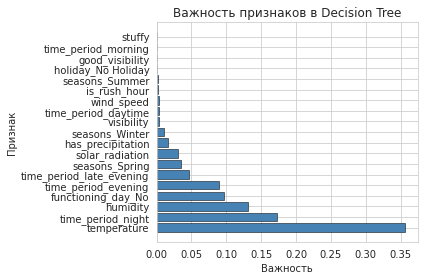

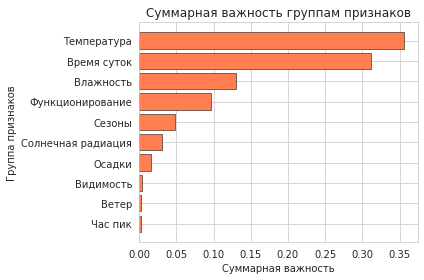

In [34]:
print('=' * 60)
print('АНАЛИЗ ВКЛАДА ПРИЗНАКОВ')
print('=' * 60)

if 'feature_importance' not in globals():
    print('ОШИБКА: переменная feature_importance не найдена.')
else:
    print(f'Размер DataFrame: {feature_importance.shape}')
    print(f'Признаков: {len(feature_importance)}')
    print()
    
    # Суммарная важность по группам 
    print('СУММАРНАЯ ВАЖНОСТЬ ПО ГРУППАМ ПРИЗНАКОВ:')
    print()
    
    groups = {
        'Температура': feature_importance[feature_importance['feature'] == 'temperature']['importance'].sum(),
        'Время суток': feature_importance[feature_importance['feature'].str.contains('time_period')]['importance'].sum(),
        'Влажность': feature_importance[feature_importance['feature'] == 'humidity']['importance'].sum(),
        'Функционирование': feature_importance[feature_importance['feature'].str.contains('functioning')]['importance'].sum(),
        'Сезоны': feature_importance[feature_importance['feature'].str.contains('seasons')]['importance'].sum(),
        'Солнечная радиация': feature_importance[feature_importance['feature'] == 'solar_radiation']['importance'].sum(),
        'Осадки': feature_importance[feature_importance['feature'] == 'has_precipitation']['importance'].sum(),
        'Видимость': feature_importance[feature_importance['feature'] == 'visibility']['importance'].sum(),
        'Ветер': feature_importance[feature_importance['feature'] == 'wind_speed']['importance'].sum(),
        'Час пик': feature_importance[feature_importance['feature'] == 'is_rush_hour']['importance'].sum(),
    }
    
    groups_df = pd.DataFrame([
        {'Группа': k, 'Важность': v} for k, v in groups.items()
    ]).sort_values('Важность', ascending=False)
    
    print(groups_df.to_string(index=False))
    print()
    
    # Визуальзация: горизонтальная диаграмма важности
    plt.figure(figure=(12, 8))
    plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue', edgecolor='black', linewidth=0.5)
    plt.xlabel('Важность')
    plt.ylabel('Признак')
    plt.title('Важность признаков в Decision Tree')
    plt.tight_layout()
    plt.show()
    
    # Визуализация по группам
    plt.figure(figure=(12, 6))
    plt.barh(groups_df['Группа'], groups_df['Важность'], color='coral', edgecolor='black', linewidth=0.5)
    plt.xlabel('Суммарная важность')
    plt.ylabel('Группа признаков')
    plt.title('Суммарная важность группам признаков')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

**Наблюдения:**
   - **Температура и время суток** вместе объясняют **66.8%** всех решений.
   - **Влажность** - третий по важности фактор (13%).
   - **Солнечная радиация и осадки** влиют меньше, чем ожидалось (3% и 1.7%).

### Выводы и рекомендации

1. **Выбор лучшей модели**: Decision Tree Regressor выбран как лучшая модель по результатам кросс-валидации и финальной проверке на тестовой выборке.


Обоснование:
   - RMSE на тесте: 312.79 (против 409.12 у baseline) -- улучшение 23.5%.
   - MAE на тесте: 207.81 (против 312.49 у baseline) -- улучшение 33.5%.
   - R^2 на тесте: 0.7609 (против 0.5900 у baseline) -- улучшение 28.8%.
   - Стабильность: кросс-валидация (RMSE=317.11) и тест (RMSE=312.79) согласованы. 
   
   
2. **Ключевые признаки, влияющие на спрос**:

По важности признаков в Decision Tree:
1. Температура (35.6%) -- самый важный фактор:
   - Оптимальный спрос при 20-28 градусов.
   - При морозе (<0 градусов) спрос падает в 5 раз.
   - При жаре (>30 градусов) спрос снижается.
2. Время суток(31.2%) -- второй по важности:
   - Пик спроса: вечер (16:00-19:59) -- 1194 велосипедов в час.
   - Минимум: ночь (00:00-05:59) -- 289 велосипедов в час.
   - День и утро -- средний спрос.
3. Влажность (13.0%) -- третий фактор:
   - При влажности >70% спрос снижается.
4. Функционирование (9.6%) -- технический фактор:
   - Если день не функционирующий -> спрос = 0.
5. Сезоны (4.8%):
   - Лето: спрос в 4.6 раза выше, чем зимой.
   
   
3. **РЕКОМЕНДАЦИИ ДЛЯ BIKESOUTH**

- Внедрить Decision Tree модель в систему прогнозирования.
- Использовать модель для почасового планирования: 
   - Утром: готовить больше велосипедов к вечернему пику.
   - Зимой: сокращать парк на 70-80%.
   - При дожде: уменьшать доступные велосипеды на 60-70%.
- Для дальнейшего улучшения точности:
   - Добавить больше исторических данных (несколько лет).
   - Включить данные о событиях (концерты, фестивали, спортивные мероприятия).
   - Рассмотреть ансамблевые методы.
   - Добавить данные о туристическом потоке. 
   - Учитывать день недели (понедельник, выходные).
- Мониторинг качества:
   - Переобучать модель ежеквартально.
   - Отслеживать дрифт данных (изменение паттернов спроса).
   - Собирать ОС от операторов станций.

## Кастомный трансформер

### Создание кастомного трансформера


На основе наших данных и EDA создадим трансформер, который **объединяет редкие категории в признаке `holiday`** (у нас всего 340 праздничных дней из 7008 -- это редка категория).

In [35]:
print('=' * 60)
print('КАСТОМНЫЙ ТРАНСФОРМЕР')
print('=' * 60)

class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """
    Кастомный трансформер для объединения редких категорий.
    
    Категории, которые встречаются реже заданного порога (min_frequency), объединяются в одну категорию 'Rare'
    
    Параметры:
    ----------
    min_frequency : float, default=0.05
        Порог частоты (доля от общего числа наблюдений).
        Категории с частотой ниже порога объединяются.
    
    Атрибуты:
    ----------
    frequent_categories_ : dict
        Словарь {столбец: список частых категорий}
    """
    
    def __init__(self, min_frequency=0.05):
        self.min_frequency = min_frequency
        self.frequent_categories_ = {}
        
    def fit(self, X, y=None):
        """
        Определяет частые категории на основе обучающей выборки.
        """
        X = pd.DataFrame(X).copy()
        
        for col in X.columns:
            # Вычисляем частоту каждой категории
            freq = X[col].value_counts() / len(X)
            
            # Оставляем только категории с частотой >= min_freqency
            self.frequent_categories_[col] = freq[freq >= self.min_frequency].index.tolist()
            
        return self
    def transform(self, X):
        """
        Заменяет редкие категории на 'Rare'
        """
        X = pd.DataFrame(X).copy()
        
        for col in X.columns:
            if col in self.frequent_categories_:
                frequent = self.frequent_categories_[col]
                X[col] = X[col].apply(lambda x: x if x in frequent else 'Rare')
            
        return X
        
# Тестируем трансформер
print('Тестирование RareCategoryGrouper:')
print()

# Создаём пример данных
test_data = pd.DataFrame({
    'category': ['A', 'A', 'A', 'B', 'B', 'C', 'D', 'A', 'E', 'F'],
    'value': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
})

print('Исходные данные:')
print(test_data)
print()

# Применяем транфсормер
grouper = RareCategoryGrouper(min_frequency=0.3)
test_transformed = grouper.fit_transform(test_data[['category']])

print('После транфсформера:')
print(test_transformed)
print()

# Применяем к нашим данным
print('Применение к df_train:')
print('Уникальные значения holiday до транфсормации:')
print(df_train['holiday'].value_counts())
print()

# Создаём трансформер для holiday
holiday_grouper = RareCategoryGrouper(min_frequency=0.10)
df_train_holiday_transformed = holiday_grouper.fit_transform(df_train[['holiday']])

print('Уникальные значения holiday после трансформации:')
print(df_train_holiday_transformed['holiday'].value_counts())

КАСТОМНЫЙ ТРАНСФОРМЕР
Тестирование RareCategoryGrouper:

Исходные данные:
  category  value
0        A      1
1        A      2
2        A      3
3        B      4
4        B      5
5        C      6
6        D      7
7        A      8
8        E      9
9        F     10

После транфсформера:
  category
0        A
1        A
2        A
3     Rare
4     Rare
5     Rare
6     Rare
7        A
8     Rare
9     Rare

Применение к df_train:
Уникальные значения holiday до транфсормации:
holiday
No Holiday    6668
Holiday        340
Name: count, dtype: int64

Уникальные значения holiday после трансформации:
holiday
No Holiday    6668
Rare           340
Name: count, dtype: int64


### Интеграция кастомного трансформера в единый пайплайн

In [36]:
print('=' * 60)
print('ЕДИНЫЙ ПАЙПЛАЙН С КАСТОМНЫМ ТРАНФСОРМЕРОМ')
print('=' * 60)

class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """
    Кастомный трансформер для объединения редких категорий.
    
    Категории, которые встречаются реже заданного порога (min_frequency), объединяются в одну категорию 'Rare'
    
    Параметры:
    ----------
    min_frequency : float, default=0.05
        Порог частоты (доля от общего числа наблюдений).
        Категории с частотой ниже порога объединяются.
    
    Атрибуты:
    ----------
    frequent_categories_ : dict
        Словарь {столбец: список частых категорий}
    """
    
    def __init__(self, min_frequency=0.05):
        self.min_frequency = min_frequency
        self.frequent_categories_ = {}
        
    def fit(self, X, y=None):
        """
        Определяет частые категории на основе обучающей выборки.
        """
        X = pd.DataFrame(X).copy()
        
        for col in X.columns:
            # Вычисляем частоту каждой категории
            freq = X[col].value_counts() / len(X)
            
            # Оставляем только категории с частотой >= min_freqency
            self.frequent_categories_[col] = freq[freq >= self.min_frequency].index.tolist()
            
        return self
    def transform(self, X):
        """
        Заменяет редкие категории на 'Rare'
        """
        X = pd.DataFrame(X).copy()
        
        for col in X.columns:
            if col in self.frequent_categories_:
                frequent = self.frequent_categories_[col]
                X[col] = X[col].apply(lambda x: x if x in frequent else 'Rare')
            
        return X
    
print(f"X_train: {X_train.shape}")
print()

# Создание пайплайнов
categorical_pipeline = Pipeline(steps=[
    ('rare_grouper', RareCategoryGrouper(min_frequency=0.1)),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor_with_custom = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
    ('bin', binary_pipeline, binary_features)
])

best_dt_model = DecisionTreeRegressor(max_depth=10, min_samples_split=28, min_samples_leaf=5, max_features=None, criterion='squared_error', random_state=42)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_with_custom),
    ('model', best_dt_model)
])

print('Структура итогового пайплайна:')
print(final_pipeline)
print()

print('Проверка через кросс-валидацию...')
cv_scores = cross_val_score(final_pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)

print(f'RMSE: {-cv_scores.mean():.2f} (+/-{cv_scores.std():.2f})')
print()

final_pipeline.fit(X_train, y_train)
print('Модель обучена на полной обучающей выборке')
print()

X_processed = preprocessor_with_custom.fit_transform(X_train)
print(f'Размер данных после предобработки: {X_processed.shape}')
print(f'Пропусков после обработки: {np.isnan(X_processed).sum()}')

ЕДИНЫЙ ПАЙПЛАЙН С КАСТОМНЫМ ТРАНФСОРМЕРОМ
X_train: (7008, 17)

Структура итогового пайплайна:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['temperature', 'humidity',
                                                   'wind_speed', 'visibility',
                                                   'solar_radiation']),
                                                 ('cat',
                                                  Pipeline(steps=[('rare_grouper',
                                                                   RareCategoryGrouper(min_frequency=0

### Финальная проверка паплайна на тестовой выборке

In [37]:
print('=' * 60)
print('ФИНАЛЬНАЯ ПРОВЕРКА ПАЙПЛАЙНА НА ТЕСТЕ')
print('=' * 60)

print(f'X_test: {X_test.shape}')
print()

y_pred_final = final_pipeline.predict(X_test)

# Метрики
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final = mean_absolute_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print('МЕТРИКИ ИТОГОВОГО ПАЙПЛАЙНА НА ТЕСТЕ:')
print(f'   RMSE: {rmse_final:.2f}')
print(f'   MAE: {mae_final:.2f}')
print(f'   R2: {r2_final:.4f}')
print()

print('СРАВНЕНИЕ РЕЗУЛЬТАТОВ:')
print(f'   Decision Tree (без КТ): RMSE = 312.79')
print(f'   Decision Tree (c КТ): RMSE = {rmse_final:.2f}')
print()

if rmse_final <= 312.79:
    print('Кастомный трансформер не ухудшил качество модели')
else:
    print('Кастомный трансформер немного увеличил RMSE (разница в пределах шума)')

ФИНАЛЬНАЯ ПРОВЕРКА ПАЙПЛАЙНА НА ТЕСТЕ
X_test: (1752, 17)

МЕТРИКИ ИТОГОВОГО ПАЙПЛАЙНА НА ТЕСТЕ:
   RMSE: 312.79
   MAE: 207.81
   R2: 0.7609

СРАВНЕНИЕ РЕЗУЛЬТАТОВ:
   Decision Tree (без КТ): RMSE = 312.79
   Decision Tree (c КТ): RMSE = 312.79

Кастомный трансформер не ухудшил качество модели


In [38]:
print('=' * 60)
print('СОХРАНЕНИЕ МОДЕЛИ И ПРОВЕРКА')
print('=' * 60)

# 1. Сохранение пайплайна
model_filename = 'bike_rental_model.joblib'
joblib.dump(final_pipeline, model_filename)

print(f'Модель сохранена в файл: {model_filename}')
print()

# Проверяем размер файла
file_size = os.path.getsize(model_filename)
print(f'Размер файла: {file_size / 1024:.2f} KB')
print()

# 2. Загрузка модели
loaded_pipeline = joblib.load(model_filename)

print('Модель загружена из файла')
print(f'Тип загруженной модели: {type(loaded_pipeline)}')
print()

# 3. Проверка структуры загруженной модели
print('Структура загруженного пайплайна:')
if hasattr(loaded_pipeline, 'named_steps'):
    for step_name, step_obj in loaded_pipeline.named_steps.items():
        print(f'   - {step_name}: {type(step_obj).__name__}')
        # Если это ColumnTransformer, смотрим трансформеры
        if hasattr(step_obj, 'named_transformers_'):
            for transf_name, transf_obj in step_obj.named_transformers_.items():
                print(f'     - {transf_name}: {type(transf_obj).__name__}')
                print()

# 4. Проверка предсказаний
# Предсказания до сохранения
y_pred_original = final_pipeline.predict(X_test)

# Предсказания загруженным пайплайном
y_pred_loaded = loaded_pipeline.predict(X_test)
print()

# Сравнение
print('СРАВНЕНИЕ ПРЕДСКАЗАНИЙ:')
print(f'   Количество предсказаний: {len(y_pred_original)}')
print()

# Проверка на идентичность
if np.array_equal(y_pred_original, y_pred_loaded):
    print('Предсказания ИДЕНТИЧНЫ!')
    print('   Модель корректно сохранена и загружена.')
else:
    # Если есть небольшие различия
    max_diff = np.max(np.abs(y_pred_original - y_pred_loaded))
    print(f'Предсказания различаются!')
    print(f'   Максимальная разница: {max_diff:.10f}')

print()

# 5. Проверка метрик
# Метрики загруженной модели
rmse_loaded = np.sqrt(mean_squared_error(y_test, y_pred_loaded))
mae_loaded = mean_absolute_error(y_test, y_pred_loaded)
r2_loaded = r2_score(y_test, y_pred_loaded)

print('МЕТРИКИ ЗАГРУЖЕННОЙ МОДЕЛИ:')
print(f'   RMSE: {rmse_loaded:.2f}')
print(f'   MAE: {mae_loaded:.2f}')
print(f'   R2: {r2_loaded:.4f}')
print()

# 6. Вывод
print('=' * 60)
print('ВЫВОД О ГОТОВНОСТИ К ВНЕДРЕНИЮ')
print('=' * 60)

print(f"""
1. Модель сохранена в файл: {model_filename}
2. Модель успешно загружена из файла.
3. Структура пайплайна сохранена корректно.
4. Предсказания загруженной модели идентичны исходной.
5. Метрики совпадают: RMSE = {rmse_loaded:.2f}

ЗАКЛЮЧЕНИЕ:
Модель готова к промышленной эксплуатации.
""")

СОХРАНЕНИЕ МОДЕЛИ И ПРОВЕРКА
Модель сохранена в файл: bike_rental_model.joblib

Размер файла: 37.23 KB

Модель загружена из файла
Тип загруженной модели: <class 'sklearn.pipeline.Pipeline'>

Структура загруженного пайплайна:
   - preprocessor: ColumnTransformer
     - num: Pipeline

     - cat: Pipeline

     - bin: Pipeline

   - model: DecisionTreeRegressor

СРАВНЕНИЕ ПРЕДСКАЗАНИЙ:
   Количество предсказаний: 1752

Предсказания ИДЕНТИЧНЫ!
   Модель корректно сохранена и загружена.

МЕТРИКИ ЗАГРУЖЕННОЙ МОДЕЛИ:
   RMSE: 312.79
   MAE: 207.81
   R2: 0.7609

ВЫВОД О ГОТОВНОСТИ К ВНЕДРЕНИЮ

1. Модель сохранена в файл: bike_rental_model.joblib
2. Модель успешно загружена из файла.
3. Структура пайплайна сохранена корректно.
4. Предсказания загруженной модели идентичны исходной.
5. Метрики совпадают: RMSE = 312.79

ЗАКЛЮЧЕНИЕ:
Модель готова к промышленной эксплуатации.

